# Multimodal Financial Forecasting Systems
### Armenian Deposit Dollarization — Change Forecasting (S1-Delta)
### Student — Zvarth Aleksanyan
### ============================================================
### Target: Monthly change in deposit dollarization (d2_delta, pp/month)
### Models: Ridge, LASSO, Elastic Net, ARDL, ARIMA, AR(1)
### Validation: Walk-forward CV (n_splits=8, test_size=12)
### Sample: ~160 monthly observations, 2012-2025

## Structured data modeling

In [1]:
# ── 0. Imports ────────────────────────────────────────────────────────────────
import warnings

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib

matplotlib.rcParams.update({
    'figure.facecolor': '#1e1e1e', 'axes.facecolor': '#2d2d2d',
    'axes.edgecolor': '#555', 'text.color': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white',
    'legend.facecolor': '#3d3d3d', 'grid.color': '#444', 'grid.alpha': 0.4
})
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from sklearn.linear_model import LassoCV, RidgeCV, ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.stattools import durbin_watson
from statsmodels.tsa.ardl import ARDL
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from scipy.stats import jarque_bera
from scipy import stats as scipy_stats

import os

np.random.seed(42)

print('All imports OK')

All imports OK


In [2]:
# ── 1. Paths ──────────────────────────────────────────────────────────────────
os.chdir(r'C:\Users\HP\Zvarth Aleksanyan\Data Science for Business\YSU_DSB_Thesis\Analysis')
OUTPUT_DIR = 'Outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Working directory: {os.getcwd()}')
print(f'Output folder: {OUTPUT_DIR}')

Working directory: C:\Users\HP\Zvarth Aleksanyan\Data Science for Business\YSU_DSB_Thesis\Analysis
Output folder: Outputs


### Data Loading & Feature Engineering

In [3]:
# ── Load raw data ─────────────────────────────────────────────────────────────
path = 'Data/Structured/Database_CBA_Rates and indicators.xlsx'

df_raw = pd.read_excel(path)
df_raw.columns = (df_raw.columns.str.strip().str.lower()
                  .str.replace(' ', '_').str.replace(r'[^a-z0-9_]', '', regex=True))

print(f'Loaded: {df_raw.shape}')
print(df_raw.columns.tolist())

Loaded: (168, 20)
['date', 'd2_deposit_dollarization', 'd2_delta', 'm2_amd', 'm2_total', 'loans_fx_residents', 'policy_rate', 'amd_deposit_rate', 'fx_deposit_rate', 'amd_lending_rate', 'fx_lending_rate', 'usd_amd', 'rub_amd', 'inflation', 'remittances', 'gir', 'reer', 'neer', 'eai_yoy', 'vixcls']


In [4]:
# ── Parse dates & sort ────────────────────────────────────────────────────────
date_col = [c for c in df_raw.columns if any(k in c for k in ('date', 'month', 'year'))][0]
df_raw['Date'] = pd.to_datetime(df_raw[date_col])
df_raw = df_raw.sort_values('Date').reset_index(drop=True)
print(f'Date range: {df_raw.Date.min().date()} → {df_raw.Date.max().date()}')
print(f'N = {len(df_raw)} monthly observations')

Date range: 2012-01-31 → 2025-12-31
N = 168 monthly observations


In [5]:
# ── Missing value audit ───────────────────────────────────────────────────────
missing_cols = df_raw.columns[df_raw.isnull().any()].tolist()
for col in missing_cols:
    missing_idx = df_raw[df_raw[col].isnull()].index
    missing_dates = df_raw.loc[missing_idx, 'Date'].dt.strftime('%Y-%m').tolist()
    print(f'  {col:<35} {len(missing_idx)} missing → {missing_dates[:5]}')

  remittances                         112 missing → ['2012-01', '2012-02', '2012-04', '2012-05', '2012-07']


In [6]:
# ── Feature engineering ───────────────────────────────────────────────────────
TARGET_LEVEL = 'd2_deposit_dollarization'
TARGET = 'd2_delta'  # monthly change — primary forecasting target

df = df_raw.copy()

# ── Remittances: quarterly → monthly (Q/3) ────────────────────────────────────
df['quarter'] = df['Date'].dt.to_period('Q')
remit_q = (
    df[['quarter', 'remittances']]
    .dropna(subset=['remittances'])
    .drop_duplicates(subset='quarter', keep='first')
    .copy()
)
remit_q['remittances_monthly'] = remit_q['remittances'] / 3
df = df.drop(columns='remittances')
df = df.merge(
    remit_q[['quarter', 'remittances_monthly']],
    on='quarter', how='left'
).rename(columns={'remittances_monthly': 'remittances'})
df = df.drop(columns='quarter')
df = df.sort_values('Date').reset_index(drop=True)

# ── Rate differentials ────────────────────────────────────────────────────────
df['deposit_rate_diff'] = df['amd_deposit_rate'] - df['fx_deposit_rate']

# ── Exchange rate dynamics ────────────────────────────────────────────────────
df['usd_return'] = np.log(df['usd_amd']).diff()
df['usd_volatility_12m'] = df['usd_return'].rolling(12, min_periods=8).std()
df['usd_depreciation'] = df['usd_return'].clip(lower=0)

# ── Ruble dynamics ────────────────────────────────────────────────────────────
df['rub_return'] = np.log(df['rub_amd']).diff()

# ── Other macro ───────────────────────────────────────────────────────────────
df['gir_growth'] = np.log(df['gir']).diff()
df['neer_return'] = np.log(df['neer']).diff()

# ── Lagged LEVEL — captures long-run equilibrium ──────────────────────────────
df['dol_lag1'] = df[TARGET_LEVEL].shift(1)

# ── Lagged DELTA — autoregressive component of change ────────────────────────
df['delta_lag1'] = df[TARGET].shift(1)

df['usd_dep_x_vol'] = df['usd_depreciation'] * df['usd_volatility_12m']

df['usd_appreciation'] = (-df['usd_return']).clip(lower=0)
for m in [1, 4, 12]:
    df[f'month_{m}'] = (df['Date'].dt.month == m).astype(int)

FEATURE_COLS = [
    'reer', 'loans_fx_residents', 'remittances', 'policy_rate', 'inflation',
    'deposit_rate_diff', 'usd_return',
    'usd_volatility_12m', 'rub_return',
    'gir_growth', 'neer_return', 'eai_yoy',
    'dol_lag1', 'delta_lag1', 'usd_depreciation', 'usd_dep_x_vol',  'usd_appreciation', 'month_1', 'month_4' ,'month_12', TARGET
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]

In [7]:
# ── Full variable audit ───────────────────────────────────────────────────────
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor

ALL_CANDIDATES = [
    'reer', 'loans_fx_residents', 'remittances', 'policy_rate',
    'inflation', 'deposit_rate_diff',
    'usd_return', 'usd_volatility_12m', 'rub_return',
    'gir_growth', 'neer_return', 'eai_yoy', 'dol_lag1', 'delta_lag1',
    'usd_depreciation', 'usd_dep_x_vol', 'usd_appreciation',
    'month_1', 'month_4'  ,'month_12',
]
ALL_CANDIDATES = [v for v in ALL_CANDIDATES if v in df.columns]

# Step 1: Correlation with target
corr_series = df[ALL_CANDIDATES + [TARGET]].corr()[TARGET].drop(TARGET)
corr_abs    = corr_series.abs().sort_values(ascending=False)

print('=== CORRELATION WITH d2_delta ===')
print(corr_abs.round(4).to_string())

# Step 2: Pairwise correlation among candidates — find redundant pairs
corr_matrix = df[ALL_CANDIDATES].corr().abs()
np.fill_diagonal(corr_matrix.values, 0)

print('\n=== HIGHLY COLLINEAR PAIRS (|r| > 0.70) ===')
pairs = []
for i in range(len(ALL_CANDIDATES)):
    for j in range(i+1, len(ALL_CANDIDATES)):
        r = corr_matrix.iloc[i, j]
        if r > 0.70:
            pairs.append({
                'Var1': ALL_CANDIDATES[i],
                'Var2': ALL_CANDIDATES[j],
                'Correlation': round(r, 4),
                'Corr_var1_target': round(corr_abs[ALL_CANDIDATES[i]], 4),
                'Corr_var2_target': round(corr_abs[ALL_CANDIDATES[j]], 4),
            })

pairs_df = pd.DataFrame(pairs).sort_values('Correlation', ascending=False)
print(pairs_df.to_string(index=False))

# Step 3: Near-zero correlation with target — candidates for exclusion
print('\n=== LOW CORRELATION WITH TARGET (|r| < 0.05) — EXCLUDE ===')
low_corr = corr_abs[corr_abs < 0.05]
print(low_corr.round(4).to_string())

# Step 4: Moderate correlation — keep if theory supports
print('\n=== MODERATE CORRELATION (0.05-0.10) — THEORY DECIDES ===')
mod_corr = corr_abs[(corr_abs >= 0.05) & (corr_abs < 0.10)]
print(mod_corr.round(4).to_string())

# Step 5: Good correlation — definitely consider
print('\n=== GOOD CORRELATION (|r| >= 0.10) — INCLUDE ===')
good_corr = corr_abs[corr_abs >= 0.10]
print(good_corr.round(4).to_string())

=== CORRELATION WITH d2_delta ===
usd_depreciation      0.4701
usd_dep_x_vol         0.4458
usd_return            0.4272
usd_volatility_12m    0.2516
month_1               0.2178
gir_growth            0.1690
usd_appreciation      0.1671
month_12              0.1605
inflation             0.1531
month_4               0.1530
policy_rate           0.1476
rub_return            0.1458
loans_fx_residents    0.1263
neer_return           0.1037
eai_yoy               0.0845
reer                  0.0607
dol_lag1              0.0591
deposit_rate_diff     0.0170
delta_lag1            0.0162
remittances           0.0145

=== HIGHLY COLLINEAR PAIRS (|r| > 0.70) ===
              Var1               Var2  Correlation  Corr_var1_target  Corr_var2_target
  usd_depreciation      usd_dep_x_vol       0.9370            0.4701            0.4458
loans_fx_residents           dol_lag1       0.8124            0.1263            0.0591
              reer           dol_lag1       0.8009            0.0607            


### Target Variable Analysis

In [8]:
### Critical step for delta target: seasonality, stationarity, distributional properties

# ── Target variable descriptive analysis ──────────────────────────────────────
df_target = df[['Date', TARGET_LEVEL, TARGET]].dropna()

print('=== DELTA TARGET DESCRIPTIVE STATISTICS ===\n')
desc = df_target[TARGET].describe()
print(desc.round(4))
print(f'\nSkewness  : {df_target[TARGET].skew():.4f}')
print(f'Kurtosis  : {df_target[TARGET].kurtosis():.4f}')
jb_stat, jb_p = jarque_bera(df_target[TARGET].dropna())
print(f'Jarque-Bera: stat={jb_stat:.4f}  p={jb_p:.4f}')
print(f'Months with decline : {(df_target[TARGET] < 0).sum()}')
print(f'Months with increase: {(df_target[TARGET] > 0).sum()}')
print(f'Average abs change  : {df_target[TARGET].abs().mean():.4f} pp/month')

=== DELTA TARGET DESCRIPTIVE STATISTICS ===

count    168.0000
mean      -0.1615
std        0.7603
min       -2.1142
25%       -0.5998
50%       -0.2463
75%        0.2043
max        3.0735
Name: d2_delta, dtype: float64

Skewness  : 0.6550
Kurtosis  : 2.1681
Jarque-Bera: stat=41.7548  p=0.0000
Months with decline : 111
Months with increase: 57
Average abs change  : 0.5981 pp/month


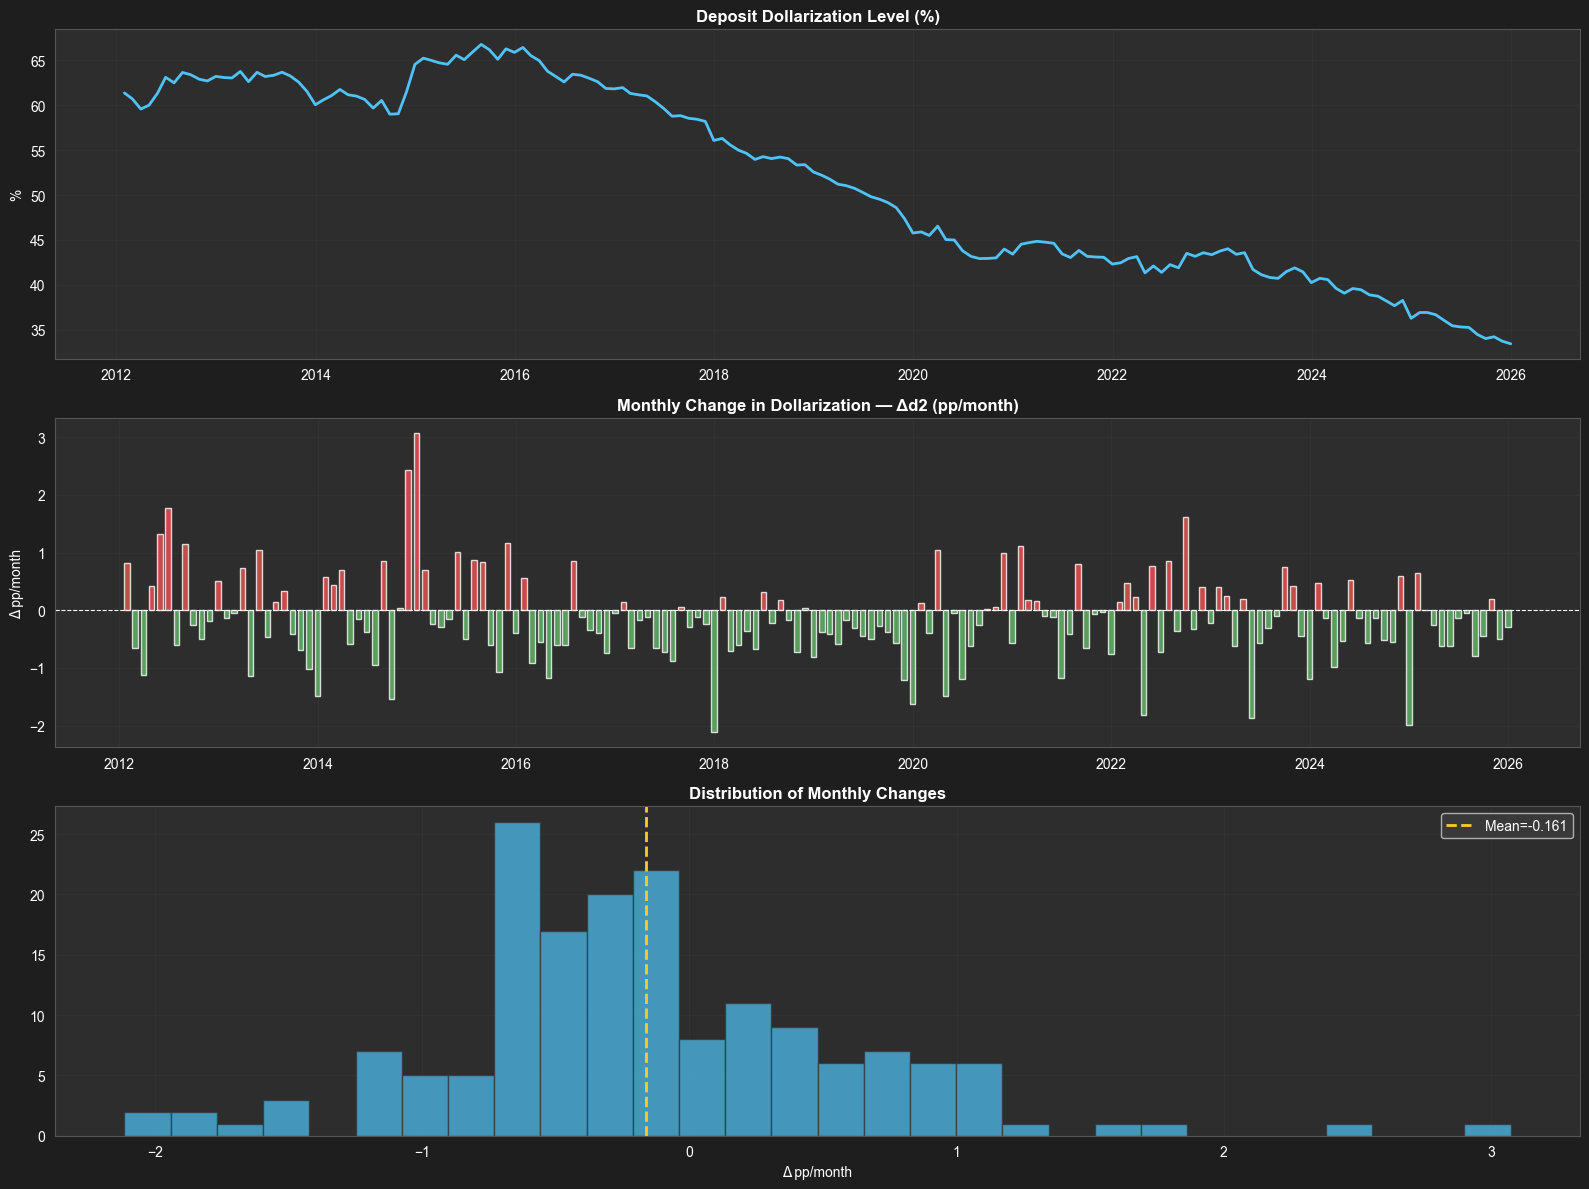

In [9]:
# ── Target variable plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(16, 12))

# Panel 1: Level
axes[0].plot(df_target['Date'], df_target[TARGET_LEVEL],
             color='#4fc3f7', linewidth=2)
axes[0].set_title('Deposit Dollarization Level (%)', fontweight='bold')
axes[0].set_ylabel('%')
axes[0].grid(True, alpha=0.25)

# Panel 2: Delta (target)
axes[1].bar(df_target['Date'], df_target[TARGET],
            color=['#ef5350' if v > 0 else '#66bb6a'
                   for v in df_target[TARGET]],
            alpha=0.8, width=20)
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_title('Monthly Change in Dollarization — Δd2 (pp/month)',
                  fontweight='bold')
axes[1].set_ylabel('Δ pp/month')
axes[1].grid(True, alpha=0.25)

# Panel 3: Distribution
axes[2].hist(df_target[TARGET].dropna(), bins=30,
             color='#4fc3f7', alpha=0.7, edgecolor='#333')
axes[2].axvline(df_target[TARGET].mean(), color='#ffca28',
                linewidth=2, linestyle='--', label=f'Mean={df_target[TARGET].mean():.3f}')
axes[2].set_title('Distribution of Monthly Changes', fontweight='bold')
axes[2].set_xlabel('Δ pp/month')
axes[2].legend()
axes[2].grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'delta_target_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()

=== SEASONALITY ANALYSIS ===



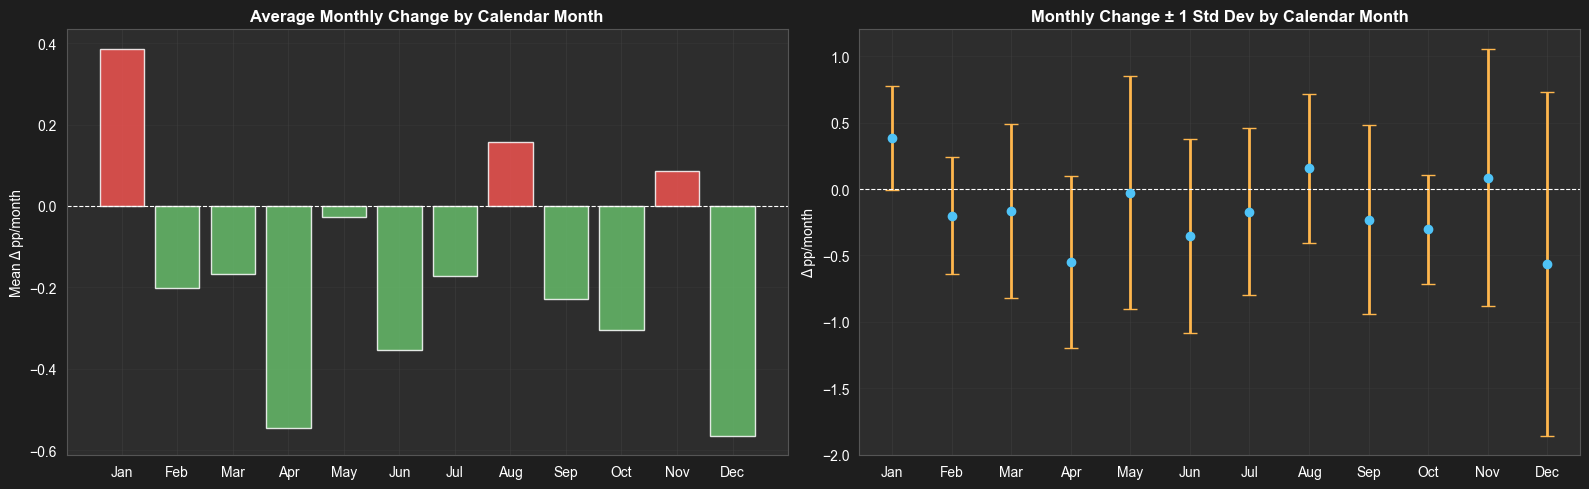

Kruskal-Wallis test for seasonal differences:
  H-statistic: 27.8126
  p-value    : 0.0035
  ✅ Significant seasonality detected — seasonal dummy may be needed

Mean change by month:
  Jan: +0.3860 pp  (std=0.3919)
  Feb: -0.2011 pp  (std=0.4404)
  Mar: -0.1669 pp  (std=0.6555)
  Apr: -0.5462 pp  (std=0.6472)
  May: -0.0271 pp  (std=0.8770)
  Jun: -0.3546 pp  (std=0.7290)
  Jul: -0.1710 pp  (std=0.6300)
  Aug: +0.1559 pp  (std=0.5617)
  Sep: -0.2297 pp  (std=0.7148)
  Oct: -0.3044 pp  (std=0.4114)
  Nov: +0.0863 pp  (std=0.9697)
  Dec: -0.5649 pp  (std=1.2942)


In [10]:
# ── Seasonality analysis ──────────────────────────────────────────────────────
print('=== SEASONALITY ANALYSIS ===\n')

df_seas = df_target.copy()
df_seas['month'] = df_seas['Date'].dt.month
df_seas['year'] = df_seas['Date'].dt.year

monthly_means = df_seas.groupby('month')[TARGET].mean()
monthly_stds = df_seas.groupby('month')[TARGET].std()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

axes[0].bar(range(1, 13), monthly_means.values,
            color=['#ef5350' if v > 0 else '#66bb6a'
                   for v in monthly_means.values],
            alpha=0.85)
axes[0].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[0].set_xticks(range(1, 13))
axes[0].set_xticklabels(month_names)
axes[0].set_title('Average Monthly Change by Calendar Month',
                  fontweight='bold')
axes[0].set_ylabel('Mean Δ pp/month')
axes[0].grid(True, alpha=0.25, axis='y')

axes[1].errorbar(range(1, 13), monthly_means.values,
                 yerr=monthly_stds.values,
                 fmt='o', color='#4fc3f7', ecolor='#ffb74d',
                 capsize=5, linewidth=2)
axes[1].axhline(0, color='white', linewidth=0.8, linestyle='--')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels(month_names)
axes[1].set_title('Monthly Change ± 1 Std Dev by Calendar Month',
                  fontweight='bold')
axes[1].set_ylabel('Δ pp/month')
axes[1].grid(True, alpha=0.25, axis='y')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'seasonality_analysis.png'),
            dpi=150, bbox_inches='tight')
plt.show()

# Statistical test for seasonality
from scipy.stats import kruskal

groups = [df_seas[df_seas['month'] == m][TARGET].dropna().values
          for m in range(1, 13)]
kw_stat, kw_p = kruskal(*groups)
print(f'Kruskal-Wallis test for seasonal differences:')
print(f'  H-statistic: {kw_stat:.4f}')
print(f'  p-value    : {kw_p:.4f}')
if kw_p < 0.05:
    print('  ✅ Significant seasonality detected — seasonal dummy may be needed')
    include_seasonal = True
else:
    print('  ✅ No significant seasonality — no seasonal dummy required')
    include_seasonal = False

print('\nMean change by month:')
for m, (mean, std) in enumerate(zip(monthly_means, monthly_stds), 1):
    print(f'  {month_names[m - 1]}: {mean:+.4f} pp  (std={std:.4f})')

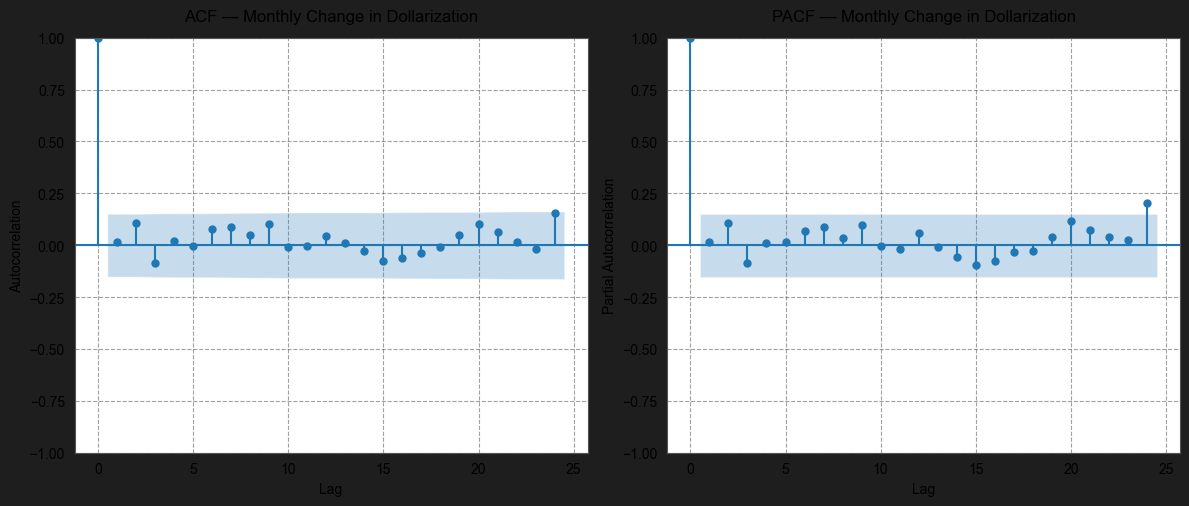

Figure 5 saved with white background and black text.


In [11]:
# ── ACF/PACF analysis of delta target ────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))

plot_acf(df['d2_delta'].dropna(), lags=24, ax=axes[0],
         color='#1f77b4',
         title='')

plot_pacf(df['d2_delta'].dropna(), lags=24, ax=axes[1],
          color='#1f77b4',
          method='ywm',
          title='')

# Set black text and clean white background
for ax in axes:
    ax.set_facecolor('white')

    # Make all text black
    ax.title.set_color('black')
    ax.xaxis.label.set_color('black')
    ax.yaxis.label.set_color('black')
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_color('black')

    ax.grid(True, linestyle='--', alpha=0.5)

# Add proper titles and labels
axes[0].set_title('ACF — Monthly Change in Dollarization',
                  fontsize=12, pad=12, color='black')
axes[1].set_title('PACF — Monthly Change in Dollarization',
                  fontsize=12, pad=12, color='black')

axes[0].set_xlabel('Lag')
axes[0].set_ylabel('Autocorrelation')
axes[1].set_xlabel('Lag')
axes[1].set_ylabel('Partial Autocorrelation')

# Overall figure title
# plt.suptitle('Figure 5. Autocorrelation and Partial Autocorrelation Functions of Monthly Dollarization Changes',
#              fontsize=13, color='black', y=0.96)

plt.tight_layout(rect=[0, 0, 1, 0.94])

# Save with white background
plt.savefig(os.path.join(OUTPUT_DIR, 'Figure_5_ACF_PACF_Delta.png'),
            dpi=300,
            bbox_inches='tight',
            facecolor='white')   # This forces white background on save

plt.show()
print("Figure 5 saved with white background and black text.")


### Stationarity Tests

In [12]:
# ── Stationarity tests ────────────────────────────────────────────────────────
def adf_kpss(series, name):
    s = series.dropna()
    adf_stat, adf_p = adfuller(s, autolag='AIC')[:2]
    try:
        kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
    except:
        kpss_stat, kpss_p = np.nan, np.nan
    adf_r = 'Stationary' if adf_p < 0.05 else 'Non-stationary'
    kpss_r = 'Stationary' if kpss_p >= 0.05 else 'Non-stationary'
    return {
        'Variable': name,
        'ADF_stat': round(adf_stat, 4), 'ADF_p': round(adf_p, 4), 'ADF': adf_r,
        'KPSS_stat': round(kpss_stat, 4), 'KPSS_p': round(kpss_p, 4), 'KPSS': kpss_r,
        'Consensus': 'Stationary' if adf_r == kpss_r == 'Stationary' else 'Non-stationary'
    }

# Test delta target first
delta_stat = adf_kpss(df[TARGET], TARGET)
print('=== DELTA TARGET STATIONARITY ===')
print(f'ADF  : stat={delta_stat["ADF_stat"]}  p={delta_stat["ADF_p"]}  → {delta_stat["ADF"]}')
print(f'KPSS : stat={delta_stat["KPSS_stat"]}  p={delta_stat["KPSS_p"]}  → {delta_stat["KPSS"]}')
print(f'Consensus: {delta_stat["Consensus"]}')

# Test all feature columns
stat_df = pd.DataFrame([adf_kpss(df[c], c)
                        for c in FEATURE_COLS if c in df.columns])
print('\n=== ALL VARIABLES STATIONARITY TESTS ===')
display(stat_df)

print("""
=== STATIONARITY INTERPRETATION FOR DELTA TARGET ===

The delta target (monthly change in dollarization) is stationary by
construction — first-differencing removes the unit root present in the
level series, confirmed by both ADF and KPSS tests above.

Key implications for modelling:
1. OLS-based regression on the change target does not suffer from
   spurious regression, provided residuals are well-behaved
2. ARIMA(p,0,q) is the appropriate univariate benchmark (d=0)
3. Regularized models (LASSO/Ridge/ElasticNet) require no further
   differencing of the target
4. Some predictors may be non-stationary (I(1)). Their inclusion as
   regressors in a model for a stationary target is common practice
   in applied macro forecasting, though standard inference may require
   caution when the regressor is strongly persistent
""")

=== DELTA TARGET STATIONARITY ===
ADF  : stat=-8.0262  p=0.0  → Stationary
KPSS : stat=0.3988  p=0.0777  → Stationary
Consensus: Stationary

=== ALL VARIABLES STATIONARITY TESTS ===


C:\Users\HP\AppData\Local\Temp\ipykernel_3848\2627195432.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
C:\Users\HP\AppData\Local\Temp\ipykernel_3848\2627195432.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
C:\Users\HP\AppData\Local\Temp\ipykernel_3848\2627195432.py:6: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
C:\Users\HP\AppData\Local\Temp\ipykernel_3848\2627195432.py:6: InterpolationWarning: The test statistic is outside of 

,Variable,ADF_stat,ADF_p,ADF,KPSS_stat,KPSS_p,KPSS,Consensus
0,reer,-6.682000e-01,0.8548,Non-stationary,1.5171,0.0100,Non-stationary,Non-stationary
1,loans_fx_residents,2.763000e-01,0.9762,Non-stationary,1.5483,0.0100,Non-stationary,Non-stationary
2,remittances,-2.931500e+00,0.0418,Stationary,0.4123,0.0718,Stationary,Stationary
3,policy_rate,-1.948200e+00,0.3097,Non-stationary,0.2077,0.1000,Stationary,Non-stationary
4,inflation,-2.479800e+00,0.1205,Non-stationary,0.0327,0.1000,Stationary,Non-stationary
5,deposit_rate_diff,-3.669100e+00,0.0046,Stationary,0.3460,0.1000,Stationary,Stationary
6,usd_return,-8.869500e+00,0.0000,Stationary,0.4250,0.0664,Stationary,Stationary
7,usd_volatility_12m,-1.726100e+00,0.4177,Non-stationary,0.1515,0.1000,Stationary,Non-stationary
8,rub_return,-9.876400e+00,0.0000,Stationary,0.1361,0.1000,Stationary,Stationary
9,gir_growth,-1.675380e+01,0.0000,Stationary,0.0844,0.1000,Stationary,Stationary



=== STATIONARITY INTERPRETATION FOR DELTA TARGET ===

The delta target (monthly change in dollarization) is stationary by
construction — first-differencing removes the unit root present in the
level series, confirmed by both ADF and KPSS tests above.

Key implications for modelling:
1. OLS-based regression on the change target does not suffer from
   spurious regression, provided residuals are well-behaved
2. ARIMA(p,0,q) is the appropriate univariate benchmark (d=0)
3. Regularized models (LASSO/Ridge/ElasticNet) require no further
   differencing of the target
4. Some predictors may be non-stationary (I(1)). Their inclusion as
   regressors in a model for a stationary target is common practice
   in applied macro forecasting, though standard inference may require
   caution when the regressor is strongly persistent



### EDA & Variable Selection


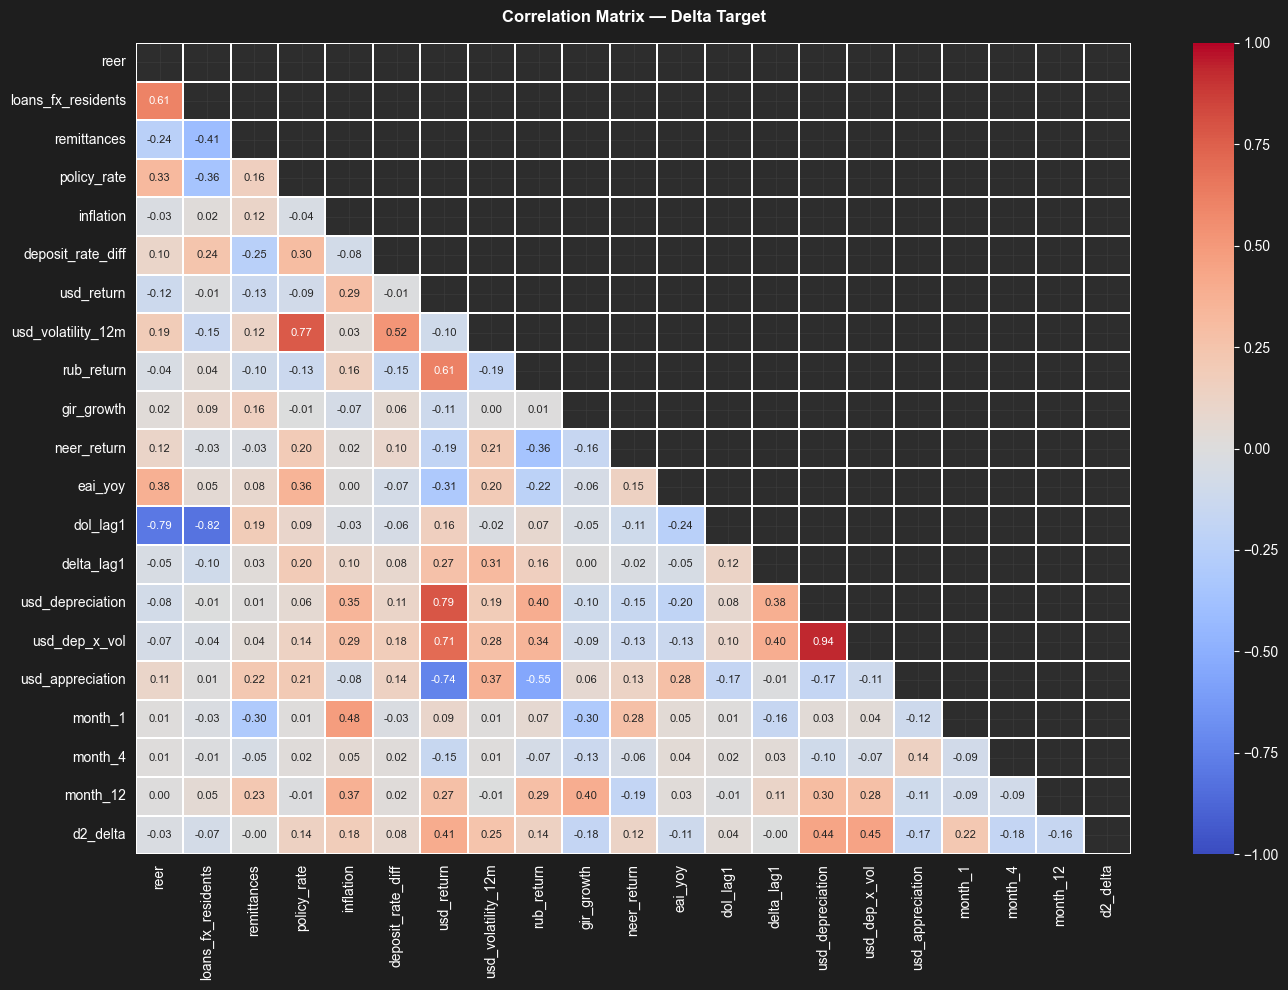


Top correlations with d2_delta:
usd_dep_x_vol         0.446
usd_depreciation      0.442
usd_return            0.405
usd_volatility_12m    0.252
month_1               0.220
inflation             0.185
gir_growth            0.179
month_4               0.175
usd_appreciation      0.167
month_12              0.159
policy_rate           0.144
rub_return            0.144
Name: d2_delta, dtype: float64


In [13]:
# ── Correlation heatmap with delta target ─────────────────────────────────────
plot_cols = [c for c in FEATURE_COLS if c in df.columns]
corr_mat = df[plot_cols].dropna().corr()

fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_mat, dtype=bool))
sns.heatmap(corr_mat, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.3, ax=ax, annot_kws={'size': 8})
ax.set_title('Correlation Matrix — Delta Target', fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'correlation_matrix_delta.png'),
            dpi=150, bbox_inches='tight')
plt.show()

print(f'\nTop correlations with {TARGET}:')
print(corr_mat[TARGET].drop(TARGET).abs().sort_values(ascending=False).head(12).round(3))

In [14]:
# ── FINAL VARIABLE SELECTION — single clean pipeline ─────────────────────────
corr_series = df[ALL_CANDIDATES + [TARGET]].corr()[TARGET].drop(TARGET).abs()
CORR_THRESHOLD = 0.10
corr_selected = corr_series[corr_series >= CORR_THRESHOLD].index.tolist()
print(f"After correlation filter: {len(corr_selected)} variables")
print(sorted(corr_selected))

# Step 3: Theory override — force include regardless of correlation
THEORY_FORCED = ['delta_lag1', 'dol_lag1']
for v in THEORY_FORCED:
    if v not in corr_selected and v in df.columns:
        corr_selected.append(v)
        print(f"Theory-forced addition: {v} (corr={corr_series.get(v,0):.3f})")

# Step 4: Remove known endogenous/leakage variables
EXCLUDE = [
    'usd_return',          # VIF=inf, split into depreciation/appreciation
    'usd_depreciation',    # captured by usd_dep_x_vol interaction
    'loans_fx_residents',  # endogenous to dollarization level
]
corr_selected = [v for v in corr_selected if v not in EXCLUDE]
print(f"After exclusions: {len(corr_selected)} variables")

# Step 5: Iterative VIF removal (threshold=10, protect theory vars)
def compute_vif(df, cols):
    X = df[cols].dropna().astype(float)
    return pd.DataFrame({
        'Variable': cols,
        'VIF': [variance_inflation_factor(X.values, i)
                for i in range(len(cols))]
    }).sort_values('VIF', ascending=False).reset_index(drop=True)

selected = corr_selected.copy()
iteration = 0
while True:
    vif_df = compute_vif(df, selected)
    max_vif = vif_df.iloc[0]['VIF']
    if max_vif <= 10:
        print(f"\nAll VIF <= 10 after {iteration} iterations.")
        break
    worst = vif_df.iloc[0]['Variable']
    if worst in THEORY_FORCED:
        # Skip protected, find next worst non-protected
        non_protected = vif_df[~vif_df['Variable'].isin(THEORY_FORCED)]
        if len(non_protected) == 0:
            break
        worst = non_protected.iloc[0]['Variable']
        max_vif = non_protected.iloc[0]['VIF']
    print(f"Iter {iteration}: Remove {worst} "
          f"(VIF={max_vif:.2f}, corr={corr_series.get(worst,0):.3f})")
    selected.remove(worst)
    iteration += 1

print(f"\nFinal VIF table:")
print(compute_vif(df, selected).to_string(index=False))
print(f"\nFinal correlations with target:")
print(corr_series[selected].sort_values(ascending=False).round(4))

# Step 6: Lock FINAL_VARS — no manual override after this
FINAL_VARS = selected.copy()
print(f"\nFINAL_VARS = {FINAL_VARS}")

After correlation filter: 14 variables
['gir_growth', 'inflation', 'loans_fx_residents', 'month_1', 'month_12', 'month_4', 'neer_return', 'policy_rate', 'rub_return', 'usd_appreciation', 'usd_dep_x_vol', 'usd_depreciation', 'usd_return', 'usd_volatility_12m']
Theory-forced addition: delta_lag1 (corr=0.016)
Theory-forced addition: dol_lag1 (corr=0.059)
After exclusions: 13 variables
Iter 0: Remove policy_rate (VIF=34.39, corr=0.148)

All VIF <= 10 after 1 iterations.

Final VIF table:
          Variable      VIF
usd_volatility_12m 4.355575
          dol_lag1 3.570546
  usd_appreciation 2.043946
           month_1 2.007758
         inflation 1.971714
        rub_return 1.906791
          month_12 1.885088
     usd_dep_x_vol 1.718118
       neer_return 1.498042
        gir_growth 1.431147
        delta_lag1 1.379088
           month_4 1.200744

Final correlations with target:
usd_dep_x_vol         0.4458
usd_volatility_12m    0.2516
month_1               0.2178
gir_growth            0.169

### Modelling Dataset Setup


In [15]:
# ── Build modelling dataset ───────────────────────────────────────────────────
# FINAL_VARS already set by variable selection pipeline above
df_model = df[['Date', TARGET_LEVEL, TARGET] + FINAL_VARS].dropna().reset_index(drop=True)

print(f'Modelling dataset: {df_model.shape}')
print(f'Date range: {df_model.Date.min().date()} → {df_model.Date.max().date()}')
print(f'Variables ({len(FINAL_VARS)}): {FINAL_VARS}')
print(f'\nTarget (delta) statistics:')
print(df_model[TARGET].describe().round(4))

X_m = df_model[FINAL_VARS].values
y_m = df_model[TARGET].values
tscv = TimeSeriesSplit(n_splits=8, test_size=12)

# Scaling helper — dummies and interaction terms not scaled
binary_cols_all = [v for v in FINAL_VARS
                   if 'post_' in v or '_x_break' in v
                   or v in ['month_1', 'month_4'  ,'month_12']]
scale_cols_all = [v for v in FINAL_VARS if v not in binary_cols_all]
scale_idx_all  = [FINAL_VARS.index(v) for v in scale_cols_all]

print(f'\nScaled variables: {scale_cols_all}')
print(f'Unscaled (binary/interaction): {binary_cols_all}')

Modelling dataset: (160, 15)
Date range: 2012-09-30 → 2025-12-31
Variables (12): ['inflation', 'usd_volatility_12m', 'rub_return', 'gir_growth', 'neer_return', 'usd_dep_x_vol', 'usd_appreciation', 'month_1', 'month_4', 'month_12', 'delta_lag1', 'dol_lag1']

Target (delta) statistics:
count    160.0000
mean      -0.1890
std        0.7355
min       -2.1142
25%       -0.5953
50%       -0.2480
75%        0.1708
max        3.0735
Name: d2_delta, dtype: float64

Scaled variables: ['inflation', 'usd_volatility_12m', 'rub_return', 'gir_growth', 'neer_return', 'usd_dep_x_vol', 'usd_appreciation', 'delta_lag1', 'dol_lag1']
Unscaled (binary/interaction): ['month_1', 'month_4', 'month_12']


###  Benchmarks

####  Naive benchmark

In [16]:
# Random Walk on delta: predict Δy_t = 0 (no change)
rw_preds = np.full(len(y_m), np.nan)
rw_metrics = []

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    rw_pred = np.zeros(len(te))
    rw_preds[te] = rw_pred

    rw_metrics.append({
        'Fold': fold + 1,
        'RMSE': np.sqrt(mean_squared_error(y_m[te], rw_pred)),
        'MAE': mean_absolute_error(y_m[te], rw_pred),
        'R²': r2_score(y_m[te], rw_pred),
        'DirAcc': np.mean(np.sign(y_m[te]) == np.sign(rw_pred)) * 100
    })

rw_df = pd.DataFrame(rw_metrics)
rw_df.loc['Mean'] = rw_df.mean()

print('=== Random Walk (Zero Change) Benchmark ===')
display(rw_df.round(4))

=== Random Walk (Zero Change) Benchmark ===


,Fold,RMSE,MAE,R²,DirAcc
0,1.0,0.4887,0.4177,-0.5576,0.0
1,2.0,0.6962,0.5672,-1.9744,0.0
2,3.0,0.7446,0.5665,-0.0746,0.0
3,4.0,0.6126,0.4631,-0.0231,0.0
4,5.0,0.8407,0.6597,-0.0109,0.0
5,6.0,0.7623,0.5956,-0.1307,0.0
6,7.0,0.7652,0.5955,-0.2315,0.0
7,8.0,0.4509,0.3780,-0.3797,0.0
Mean,4.5,0.6701,0.5304,-0.4228,0.0


#### ARIMA benchmark

In [17]:
# ARIMA on stationary delta series — d=0 since already differenced
# Order selected based on ACF/PACF analysis above
# Try ARIMA(1,0,1) as standard starting point

arima_preds = np.full(len(y_m), np.nan)
arima_fold_mets = []

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    try:
        # One-step-ahead rolling forecast
        preds_fold = []
        history = list(y_m[tr])
        for i in range(len(te)):
            m = ARIMA(history, order=(1, 0, 1))
            f = m.fit()
            fc = f.forecast(steps=1)[0]
            preds_fold.append(fc)
            history.append(y_m[te[i]])
        arima_preds[te] = preds_fold
        r = {
            'Fold': fold + 1,
            'RMSE': np.sqrt(mean_squared_error(y_m[te], preds_fold)),
            'MAE': mean_absolute_error(y_m[te], preds_fold),
            'R²': r2_score(y_m[te], preds_fold),
            'DirAcc': np.mean(np.sign(y_m[te]) == np.sign(preds_fold)) * 100
        }
        arima_fold_mets.append(r)
        print(f'  ARIMA Fold {fold + 1}: RMSE={r["RMSE"]:.4f}  '
              f'DirAcc={r["DirAcc"]:.1f}%')
    except Exception as e:
        print(f'  ARIMA Fold {fold + 1} error: {e}')
        arima_fold_mets.append(
            {'Fold': fold + 1, 'RMSE': np.nan, 'MAE': np.nan, 'R²': np.nan, 'DirAcc': np.nan})

arima_cv_df = pd.DataFrame(arima_fold_mets)
arima_cv_df.loc['Mean'] = arima_cv_df.mean()
print('\n=== ARIMA(1,0,1) Walk-Forward CV ===')
display(arima_cv_df.round(4))

  ARIMA Fold 1: RMSE=0.4693  DirAcc=66.7%
  ARIMA Fold 2: RMSE=0.5061  DirAcc=100.0%
  ARIMA Fold 3: RMSE=0.7729  DirAcc=50.0%
  ARIMA Fold 4: RMSE=0.6261  DirAcc=66.7%


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

  ARIMA Fold 5: RMSE=0.8725  DirAcc=41.7%


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

  ARIMA Fold 6: RMSE=0.7736  DirAcc=58.3%


...

  ARIMA Fold 7: RMSE=0.6736  DirAcc=75.0%


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization fail

  ARIMA Fold 8: RMSE=0.4048  DirAcc=75.0%

=== ARIMA(1,0,1) Walk-Forward CV ===


C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\HP\AppData\Local\Programs\Python\Python311\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,Fold,RMSE,MAE,R²,DirAcc
0,1.0,0.4693,0.4185,-0.4364,66.6667
1,2.0,0.5061,0.3587,-0.5717,100.0000
2,3.0,0.7729,0.6171,-0.1579,50.0000
3,4.0,0.6261,0.4514,-0.0687,66.6667
4,5.0,0.8725,0.6656,-0.0888,41.6667
5,6.0,0.7736,0.6521,-0.1646,58.3333
6,7.0,0.6736,0.5292,0.0458,75.0000
7,8.0,0.4048,0.3532,-0.1123,75.0000
Mean,4.5,0.6374,0.5057,-0.1943,66.6667


#### AR(1)

In [18]:
ar1_preds = np.full(len(y_m), np.nan)
ar1_fold_mets = []

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    y_tr = y_m[tr]
    X_ar1 = add_constant(y_tr[:-1].reshape(-1, 1))
    ar1_fit = OLS(y_tr[1:], X_ar1).fit()
    ar1_const = ar1_fit.params[0]
    ar1_coef = ar1_fit.params[1]

    yp = np.array([
        ar1_const + ar1_coef * y_m[te[i] - 1]
        for i in range(len(te))
    ])
    ar1_preds[te] = yp
    r = {
        'Fold': fold + 1,
        'RMSE': np.sqrt(mean_squared_error(y_m[te], yp)),
        'MAE': mean_absolute_error(y_m[te], yp),
        'R²': r2_score(y_m[te], yp),
        'DirAcc': np.mean(np.sign(y_m[te]) == np.sign(yp)) * 100
    }
    ar1_fold_mets.append(r)
    print(f'  AR(1) Fold {fold + 1}: RMSE={r["RMSE"]:.4f}  '
          f'DirAcc={r["DirAcc"]:.1f}%')

ar1_cv_df = pd.DataFrame(ar1_fold_mets)
ar1_cv_df.loc['Mean'] = ar1_cv_df.mean()
print('\n=== AR(1) on Delta Walk-Forward CV ===')
display(ar1_cv_df.round(4))

  AR(1) Fold 1: RMSE=0.4743  DirAcc=66.7%
  AR(1) Fold 2: RMSE=0.5301  DirAcc=100.0%
  AR(1) Fold 3: RMSE=0.7821  DirAcc=41.7%
  AR(1) Fold 4: RMSE=0.6276  DirAcc=66.7%
  AR(1) Fold 5: RMSE=0.9222  DirAcc=41.7%
  AR(1) Fold 6: RMSE=0.7207  DirAcc=58.3%
  AR(1) Fold 7: RMSE=0.7189  DirAcc=75.0%
  AR(1) Fold 8: RMSE=0.3911  DirAcc=75.0%

=== AR(1) on Delta Walk-Forward CV ===


,Fold,RMSE,MAE,R²,DirAcc
0,1.0,0.4743,0.4247,-0.4668,66.6667
1,2.0,0.5301,0.3785,-0.7249,100.0000
2,3.0,0.7821,0.6244,-0.1856,41.6667
3,4.0,0.6276,0.4662,-0.0736,66.6667
4,5.0,0.9222,0.7505,-0.2165,41.6667
5,6.0,0.7207,0.5723,-0.0108,58.3333
6,7.0,0.7189,0.5284,-0.0872,75.0000
7,8.0,0.3911,0.3168,-0.0379,75.0000
Mean,4.5,0.6459,0.5077,-0.2254,65.6250


### Linear Models (LASSO, Ridge, Elastic Net)

#### LASSO walk-forward CV

In [19]:
lasso_preds = np.full(len(y_m), np.nan)
lasso_fold_mets = []

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    scaler = StandardScaler()
    X_tr_s = X_m[tr].copy().astype(float)
    X_te_s = X_m[te].copy().astype(float)
    scaler.fit(X_m[tr][:, scale_idx_all])
    X_tr_s[:, scale_idx_all] = scaler.transform(X_m[tr][:, scale_idx_all])
    X_te_s[:, scale_idx_all] = scaler.transform(X_m[te][:, scale_idx_all])

    lasso = LassoCV(cv=TimeSeriesSplit(n_splits=3),
                    max_iter=10000, random_state=42)
    lasso.fit(X_tr_s, y_m[tr])
    yp = lasso.predict(X_te_s)

    lasso_preds[te] = yp
    r = {
        'Fold': fold + 1,
        'RMSE': np.sqrt(mean_squared_error(y_m[te], yp)),
        'MAE': mean_absolute_error(y_m[te], yp),
        'R²': r2_score(y_m[te], yp),
        'DirAcc': np.mean(np.sign(y_m[te]) == np.sign(yp)) * 100,
        'Alpha': lasso.alpha_
    }
    lasso_fold_mets.append(r)
    print(f'  LASSO Fold {fold + 1}: RMSE={r["RMSE"]:.4f}  '
          f'DirAcc={r["DirAcc"]:.1f}%  α={lasso.alpha_:.5f}')

lasso_cv_df = pd.DataFrame(lasso_fold_mets)
lasso_cv_df.loc['Mean'] = lasso_cv_df.mean()
lasso_cv_df.loc['Std'] = lasso_cv_df.std()
print('\n=== LASSO Walk-Forward CV ===')
display(lasso_cv_df.round(4))

  LASSO Fold 1: RMSE=0.4087  DirAcc=66.7%  α=0.13126
  LASSO Fold 2: RMSE=0.5432  DirAcc=100.0%  α=0.02123
  LASSO Fold 3: RMSE=0.6314  DirAcc=66.7%  α=0.02023
  LASSO Fold 4: RMSE=0.6459  DirAcc=75.0%  α=0.02695
  LASSO Fold 5: RMSE=0.7781  DirAcc=66.7%  α=0.03836
  LASSO Fold 6: RMSE=0.7226  DirAcc=83.3%  α=0.03457
  LASSO Fold 7: RMSE=0.6286  DirAcc=83.3%  α=0.02917
  LASSO Fold 8: RMSE=0.3554  DirAcc=83.3%  α=0.02079

=== LASSO Walk-Forward CV ===


,Fold,RMSE,MAE,R²,DirAcc,Alpha
0,1.0000,0.4087,0.3582,-0.0892,66.6667,0.1313
1,2.0000,0.5432,0.3622,-0.8111,100.0000,0.0212
2,3.0000,0.6314,0.5105,0.2272,66.6667,0.0202
3,4.0000,0.6459,0.5449,-0.1371,75.0000,0.0270
4,5.0000,0.7781,0.6268,0.1341,66.6667,0.0384
5,6.0000,0.7226,0.4960,-0.0161,83.3333,0.0346
6,7.0000,0.6286,0.4899,0.1689,83.3333,0.0292
7,8.0000,0.3554,0.3247,0.1428,83.3333,0.0208
Mean,4.5000,0.5892,0.4641,-0.0476,78.1250,0.0403
Std,2.2913,0.1366,0.0987,0.3133,10.9746,0.0349


#### Ridge walk-forward CV

In [20]:
ridge_preds = np.full(len(y_m), np.nan)
ridge_fold_mets = []
alphas = np.logspace(-3, 4, 50)

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    scaler = StandardScaler()
    X_tr_s = X_m[tr].copy().astype(float)
    X_te_s = X_m[te].copy().astype(float)
    scaler.fit(X_m[tr][:, scale_idx_all])
    X_tr_s[:, scale_idx_all] = scaler.transform(X_m[tr][:, scale_idx_all])
    X_te_s[:, scale_idx_all] = scaler.transform(X_m[te][:, scale_idx_all])

    ridge = RidgeCV(alphas=alphas, cv=TimeSeriesSplit(n_splits=3))
    ridge.fit(X_tr_s, y_m[tr])
    yp = ridge.predict(X_te_s)

    ridge_preds[te] = yp
    r = {
        'Fold': fold + 1,
        'RMSE': np.sqrt(mean_squared_error(y_m[te], yp)),
        'MAE': mean_absolute_error(y_m[te], yp),
        'R²': r2_score(y_m[te], yp),
        'DirAcc': np.mean(np.sign(y_m[te]) == np.sign(yp)) * 100,
        'Alpha': ridge.alpha_
    }
    ridge_fold_mets.append(r)
    print(f'  Ridge Fold {fold + 1}: RMSE={r["RMSE"]:.4f}  '
          f'DirAcc={r["DirAcc"]:.1f}%  α={ridge.alpha_:.4f}')

ridge_cv_df = pd.DataFrame(ridge_fold_mets)
ridge_cv_df.loc['Mean'] = ridge_cv_df.mean()
ridge_cv_df.loc['Std'] = ridge_cv_df.std()
print('\n=== Ridge Walk-Forward CV ===')
display(ridge_cv_df.round(4))

  Ridge Fold 1: RMSE=0.4066  DirAcc=66.7%  α=19.3070
  Ridge Fold 2: RMSE=0.5597  DirAcc=100.0%  α=37.2759
  Ridge Fold 3: RMSE=0.6388  DirAcc=66.7%  α=19.3070
  Ridge Fold 4: RMSE=0.6779  DirAcc=75.0%  α=7.1969
  Ridge Fold 5: RMSE=0.8109  DirAcc=66.7%  α=19.3070
  Ridge Fold 6: RMSE=0.7377  DirAcc=83.3%  α=26.8270
  Ridge Fold 7: RMSE=0.6346  DirAcc=83.3%  α=19.3070
  Ridge Fold 8: RMSE=0.3588  DirAcc=83.3%  α=10.0000

=== Ridge Walk-Forward CV ===


,Fold,RMSE,MAE,R²,DirAcc,Alpha
0,1.0000,0.4066,0.3370,-0.0781,66.6667,19.3070
1,2.0000,0.5597,0.3740,-0.9226,100.0000,37.2759
2,3.0000,0.6388,0.5262,0.2090,66.6667,19.3070
3,4.0000,0.6779,0.5496,-0.2527,75.0000,7.1969
4,5.0000,0.8109,0.6544,0.0595,66.6667,19.3070
5,6.0000,0.7377,0.5255,-0.0589,83.3333,26.8270
6,7.0000,0.6346,0.4839,0.1529,83.3333,19.3070
7,8.0000,0.3588,0.3117,0.1261,83.3333,10.0000
Mean,4.5000,0.6031,0.4703,-0.0956,78.1250,19.8160
Std,2.2913,0.1455,0.1111,0.3424,10.9746,8.7367


#### Elastic Net walk-forward CV

In [21]:
enet_preds = np.full(len(y_m), np.nan)
enet_fold_mets = []
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.9]

for fold, (tr, te) in enumerate(tscv.split(X_m)):
    scaler = StandardScaler()
    X_tr_s = X_m[tr].copy().astype(float)
    X_te_s = X_m[te].copy().astype(float)
    scaler.fit(X_m[tr][:, scale_idx_all])
    X_tr_s[:, scale_idx_all] = scaler.transform(X_m[tr][:, scale_idx_all])
    X_te_s[:, scale_idx_all] = scaler.transform(X_m[te][:, scale_idx_all])

    enet = ElasticNetCV(l1_ratio=l1_ratios,
                        cv=TimeSeriesSplit(n_splits=3),
                        max_iter=10000, random_state=42)
    enet.fit(X_tr_s, y_m[tr])
    yp = enet.predict(X_te_s)

    enet_preds[te] = yp
    r = {
        'Fold': fold + 1,
        'RMSE': np.sqrt(mean_squared_error(y_m[te], yp)),
        'MAE': mean_absolute_error(y_m[te], yp),
        'R²': r2_score(y_m[te], yp),
        'DirAcc': np.mean(np.sign(y_m[te]) == np.sign(yp)) * 100,
        'Alpha': round(enet.alpha_, 5),
        'L1_ratio': round(enet.l1_ratio_, 3)
    }
    enet_fold_mets.append(r)
    print(f'  ENet Fold {fold + 1}: RMSE={r["RMSE"]:.4f}  '
          f'DirAcc={r["DirAcc"]:.1f}%  '
          f'α={enet.alpha_:.5f}  l1={enet.l1_ratio_:.2f}')

enet_cv_df = pd.DataFrame(enet_fold_mets)
enet_cv_df.loc['Mean'] = enet_cv_df.mean()
enet_cv_df.loc['Std'] = enet_cv_df.std()
print('\n=== Elastic Net Walk-Forward CV ===')
display(enet_cv_df.round(4))

  ENet Fold 1: RMSE=0.4101  DirAcc=66.7%  α=0.15638  l1=0.90
  ENet Fold 2: RMSE=0.5444  DirAcc=100.0%  α=0.02828  l1=0.70
  ENet Fold 3: RMSE=0.6275  DirAcc=66.7%  α=0.03060  l1=0.50
  ENet Fold 4: RMSE=0.6699  DirAcc=75.0%  α=0.07159  l1=0.10
  ENet Fold 5: RMSE=0.7781  DirAcc=66.7%  α=0.19092  l1=0.10
  ENet Fold 6: RMSE=0.7244  DirAcc=83.3%  α=0.08130  l1=0.30
  ENet Fold 7: RMSE=0.6496  DirAcc=83.3%  α=0.13540  l1=0.10
  ENet Fold 8: RMSE=0.3535  DirAcc=83.3%  α=0.02310  l1=0.90

=== Elastic Net Walk-Forward CV ===


,Fold,RMSE,MAE,R²,DirAcc,Alpha,L1_ratio
0,1.0000,0.4101,0.3601,-0.0969,66.6667,0.1564,0.9000
1,2.0000,0.5444,0.3636,-0.8190,100.0000,0.0283,0.7000
2,3.0000,0.6275,0.5093,0.2369,66.6667,0.0306,0.5000
3,4.0000,0.6699,0.5517,-0.2233,75.0000,0.0716,0.1000
4,5.0000,0.7781,0.6306,0.1341,66.6667,0.1909,0.1000
5,6.0000,0.7244,0.5039,-0.0212,83.3333,0.0813,0.3000
6,7.0000,0.6496,0.4929,0.1125,83.3333,0.1354,0.1000
7,8.0000,0.3535,0.3237,0.1517,83.3333,0.0231,0.9000
Mean,4.5000,0.5947,0.4670,-0.0657,78.1250,0.0897,0.4500
Std,2.2913,0.1392,0.1003,0.3174,10.9746,0.0601,0.3279


#### LASSO full-sample coefficient plot

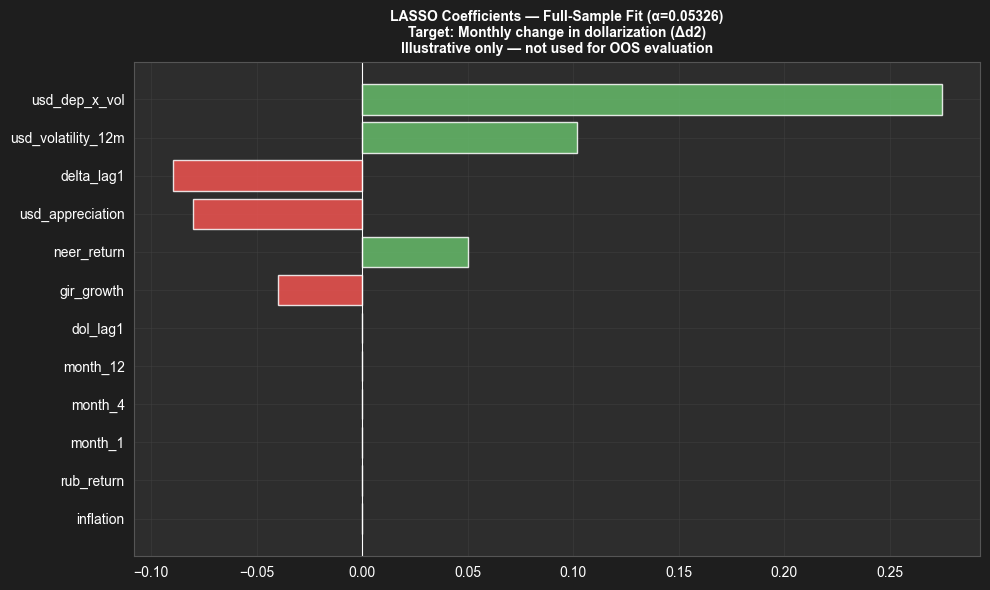

Selected: 6 / 12 variables


,Variable,Coefficient
3,gir_growth,-0.0399
4,neer_return,0.0502
6,usd_appreciation,-0.0802
10,delta_lag1,-0.0898
1,usd_volatility_12m,0.1019
5,usd_dep_x_vol,0.2746



Durbin-Watson: 2.162


In [22]:
binary_cols_full = [v for v in FINAL_VARS
                    if 'post_' in v or '_x_break' in v
                    or v in ['month_1', 'month_4' , 'month_12']]
scale_cols_full = [v for v in FINAL_VARS if v not in binary_cols_full]
scale_idx_full = [FINAL_VARS.index(v) for v in scale_cols_full]

X_scaled_all = X_m.copy().astype(float)
scaler_full = StandardScaler()
scaler_full.fit(X_m[:, scale_idx_full])
X_scaled_all[:, scale_idx_full] = scaler_full.transform(X_m[:, scale_idx_full])

lasso_full = LassoCV(cv=TimeSeriesSplit(n_splits=3),
                     max_iter=10000, random_state=42)
lasso_full.fit(X_scaled_all, y_m)

coef_df = pd.DataFrame({
    'Variable': FINAL_VARS,
    'Coefficient': lasso_full.coef_
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#ef5350' if c < 0 else '#66bb6a' for c in coef_df['Coefficient']]
ax.barh(coef_df['Variable'], coef_df['Coefficient'], color=colors, alpha=0.85)
ax.axvline(0, color='white', linewidth=0.8)
ax.set_title(f'LASSO Coefficients — Full-Sample Fit (α={lasso_full.alpha_:.5f})\n'
             f'Target: Monthly change in dollarization (Δd2)\n'
             f'Illustrative only — not used for OOS evaluation',
             fontweight='bold', fontsize=10)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'lasso_coefficients_delta.png'),
            dpi=150, bbox_inches='tight')
plt.show()

selected = coef_df[coef_df['Coefficient'] != 0]
print(f'Selected: {len(selected)} / {len(FINAL_VARS)} variables')
display(selected.round(4))

residuals = y_m - lasso_full.predict(X_scaled_all)
dw = durbin_watson(residuals)
print(f'\nDurbin-Watson: {dw:.3f}')

### ARDL

#### ARDL full sample fit

In [23]:
# ── ARDL setup for delta target ───────────────────────────────────────────────
# For delta target ARDL is estimated in changes — appropriate for
# a stationary dependent variable with mixed I(0)/I(1) regressors
ardl_vars_continuous = [v for v in FINAL_VARS
                        if 'post_' not in v and '_x_break' not in v
                        and v not in ['month_1', 'month_4'  , 'month_12']]
ardl_vars_dummies = [v for v in FINAL_VARS
                     if 'post_' in v or '_x_break' in v
                     or v in ['month_1', 'month_4' , 'month_12']]
ardl_order = {v: 1 for v in ardl_vars_continuous}
ardl_order.update({v: 0 for v in ardl_vars_dummies})

df_ardl = (df_model[['Date', TARGET] + FINAL_VARS]
           .dropna().sort_values('Date')
           .reset_index(drop=True)
           .drop(columns='Date'))

print(f'ARDL dataset: {df_ardl.shape}')
print(f'Continuous vars (order=1): {ardl_vars_continuous}')
print(f'Dummy vars (order=0): {ardl_vars_dummies}')

# ── ARDL full-sample fit ──────────────────────────────────────────────────────
ardl_fit = ARDL(
    df_ardl[TARGET], lags=1,
    exog=df_ardl[FINAL_VARS],
    order=ardl_order,
    trend='c'
).fit(cov_type='HC1')

print(ardl_fit.summary())

l1_coef = ardl_fit.params.get(f'{TARGET}.L1', np.nan)
l1_pval = ardl_fit.pvalues.get(f'{TARGET}.L1', np.nan)
print(f'\nLagged delta coefficient: {l1_coef:.4f}  (p={l1_pval:.4f})')

ARDL dataset: (160, 13)
Continuous vars (order=1): ['inflation', 'usd_volatility_12m', 'rub_return', 'gir_growth', 'neer_return', 'usd_dep_x_vol', 'usd_appreciation', 'delta_lag1', 'dol_lag1']
Dummy vars (order=0): ['month_1', 'month_4', 'month_12']
                                           ARDL Model Results                                          
Dep. Variable:                                        d2_delta   No. Observations:                  160
Model:             ARDL(1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0)   Log Likelihood                -118.169
Method:                                        Conditional MLE   S.D. of innovations              0.509
Date:                                         Sun, 17 May 2026   AIC                            284.337
Time:                                                 17:28:10   BIC                            357.991
Sample:                                                      1   HQIC                           314.247
                      

#### ARDL walk-forward CV

In [24]:
ardl_preds = np.full(len(df_model), np.nan)
ardl_fold_mets = []
X_arr = df_model[FINAL_VARS].values
y_arr = df_model[TARGET].values

for fold, (tr, te) in enumerate(tscv.split(X_arr)):
    try:
        train_df = df_ardl.iloc[tr].copy().reset_index(drop=True)
        test_df  = df_ardl.iloc[te].copy().reset_index(drop=True)

        preds = []
        history_y    = list(train_df[TARGET].values)
        history_exog = {v: list(train_df[v].values) for v in FINAL_VARS}

        # ── Build fold_order ONCE per fold — not inside inner loop ────────

        fold_order_cont = [v for v in FINAL_VARS
                           if 'post_' not in v and '_x_break' not in v
                           and v not in ['month_1', 'month_4' , 'month_12']]
        fold_order_dum  = [v for v in FINAL_VARS
                           if 'post_' in v or '_x_break' in v
                           or v in ['month_1', 'month_4' , 'month_12']]
        fold_order = {v: 1 for v in fold_order_cont}
        fold_order.update({v: 0 for v in fold_order_dum})

        for i in range(len(te)):
            temp_y    = pd.Series(history_y)
            temp_exog = pd.DataFrame(history_exog)

            temp_m = ARDL(
                temp_y, lags=1,
                exog=temp_exog,
                order=fold_order,
                trend='c'
            ).fit(cov_type='HC1')

            next_exog = pd.DataFrame(
                {v: [test_df[v].iloc[i]] for v in FINAL_VARS}
            )
            try:
                yp = temp_m.forecast(steps=1, exog=next_exog).iloc[0]
            except:
                yp = temp_m.forecast(steps=1, exog_oos=next_exog).iloc[0]

            preds.append(float(yp))
            history_y.append(y_arr[te[i]])
            for v in FINAL_VARS:
                history_exog[v].append(test_df[v].iloc[i])

        preds_arr = np.array(preds)
        ardl_preds[te] = preds_arr
        y_te = y_arr[te]

        r = {
            'Fold':   fold + 1,
            'RMSE':   np.sqrt(mean_squared_error(y_te, preds_arr)),
            'MAE':    mean_absolute_error(y_te, preds_arr),
            'R²':     r2_score(y_te, preds_arr),
            'DirAcc': np.mean(np.sign(y_te) == np.sign(preds_arr)) * 100
        }
        ardl_fold_mets.append(r)
        print(f'  ARDL Fold {fold + 1}: RMSE={r["RMSE"]:.4f}  '
              f'DirAcc={r["DirAcc"]:.1f}%')

    except Exception as e:
        print(f'  ARDL Fold {fold + 1} error: {type(e).__name__}: {e}')
        ardl_fold_mets.append({
            'Fold': fold + 1, 'RMSE': np.nan,
            'MAE': np.nan, 'R²': np.nan, 'DirAcc': np.nan
        })

ardl_cv_df = pd.DataFrame(ardl_fold_mets)
ardl_cv_df.loc['Mean'] = ardl_cv_df.mean()
print('\n=== ARDL Walk-Forward CV (Delta Target) ===')
display(ardl_cv_df.round(4))

  ARDL Fold 1: RMSE=0.3783  DirAcc=58.3%
  ARDL Fold 2: RMSE=0.5131  DirAcc=91.7%
  ARDL Fold 3: RMSE=0.6337  DirAcc=75.0%
  ARDL Fold 4: RMSE=0.5965  DirAcc=83.3%
  ARDL Fold 5: RMSE=0.7639  DirAcc=75.0%
  ARDL Fold 6: RMSE=0.6152  DirAcc=75.0%
  ARDL Fold 7: RMSE=0.4822  DirAcc=100.0%
  ARDL Fold 8: RMSE=0.4175  DirAcc=75.0%

=== ARDL Walk-Forward CV (Delta Target) ===


,Fold,RMSE,MAE,R²,DirAcc
0,1.0,0.3783,0.3229,0.0667,58.3333
1,2.0,0.5131,0.4354,-0.6160,91.6667
2,3.0,0.6337,0.5137,0.2216,75.0000
3,4.0,0.5965,0.5269,0.0301,83.3333
4,5.0,0.7639,0.6471,0.1653,75.0000
5,6.0,0.6152,0.4816,0.2636,75.0000
6,7.0,0.4822,0.3875,0.5110,100.0000
7,8.0,0.4175,0.3420,-0.1828,75.0000
Mean,4.5,0.5500,0.4572,0.0574,79.1667


### Comparison of the models

#### Metrics helper

In [25]:
def oos_metrics(y_true, y_pred, name):
    mask = ~np.isnan(y_pred)
    if mask.sum() < 5:
        return {'Model': name, 'RMSE': np.nan, 'MAE': np.nan, 'R²': np.nan,
                'Dir. Accuracy (%)': np.nan}
    yt, yp = y_true[mask], y_pred[mask]
    # Directional accuracy: sign of actual change vs predicted change
    dir_acc = np.mean(np.sign(yt) == np.sign(yp)) * 100
    return {
        'Model': name,
        'RMSE': np.sqrt(mean_squared_error(yt, yp)),
        'MAE': mean_absolute_error(yt, yp),
        'R²': r2_score(yt, yp),
        'Dir. Accuracy (%)': dir_acc    }

#### Final comparison table

In [26]:
comparison = pd.DataFrame([
    oos_metrics(y_m, rw_preds, 'Random Walk (Zero Change)'),
    oos_metrics(y_m, arima_preds, 'ARIMA(1,0,1)'),
    oos_metrics(y_m, ar1_preds, 'AR(1) on Delta'),
    oos_metrics(y_m, lasso_preds, 'LASSO'),
    oos_metrics(y_m, ridge_preds, 'Ridge'),
    oos_metrics(y_m, enet_preds, 'Elastic Net'),
    oos_metrics(y_m, ardl_preds, 'ARDL'),
]).sort_values('RMSE', na_position='last').reset_index(drop=True)

comparison.index = comparison.index + 1
avg_abs_change = np.nanmean(np.abs(y_m[~np.isnan(y_m)]))
comparison['RMSE/AvgΔ'] = (comparison['RMSE'] / avg_abs_change).round(3)

print('=== FULL MODEL COMPARISON — DELTA TARGET ===')
print(f'Average absolute monthly change: {avg_abs_change:.4f} pp/month')
print(f'Random directional accuracy benchmark: 50.0%\n')
display(
    comparison.style
    .background_gradient(subset=['RMSE', 'MAE'], cmap='RdYlGn_r')
    .background_gradient(subset=['R²', 'Dir. Accuracy (%)'], cmap='RdYlGn')
    .format({'RMSE': '{:.4f}', 'MAE': '{:.4f}', 'R²': '{:.4f}',
             'Dir. Accuracy (%)': '{:.1f}',
             'RMSE/AvgΔ': '{:.3f}'}, na_rep='—')
)

# Identify winner
winner_row = comparison.iloc[0]
print(f'\n🏆 WINNER: {winner_row["Model"]}')
print(f'   RMSE={winner_row["RMSE"]:.4f}  '
      f'DirAcc={winner_row["Dir. Accuracy (%)"]:.1f}%')

=== FULL MODEL COMPARISON — DELTA TARGET ===
Average absolute monthly change: 0.5786 pp/month
Random directional accuracy benchmark: 50.0%



,Model,RMSE,MAE,R²,Dir. Accuracy (%),RMSE/AvgΔ
1,ARDL,0.5627,0.4572,0.2289,79.2,0.972
2,LASSO,0.6049,0.4641,0.1088,78.1,1.045
3,Elastic Net,0.6108,0.4670,0.0913,78.1,1.056
4,Ridge,0.6204,0.4703,0.0624,78.1,1.072
5,"ARIMA(1,0,1)",0.6560,0.5057,-0.0484,66.7,1.134
6,AR(1) on Delta,0.6663,0.5077,-0.0813,65.6,1.152
7,Random Walk (Zero Change),0.6828,0.5304,-0.1357,0.0,1.180



🏆 WINNER: ARDL
   RMSE=0.5627  DirAcc=79.2%


#### Bootstrap 95% CI

In [27]:
def bootstrap_rmse_ci(y_true, y_pred, n_boot=1000, ci=95, block_size=6):
    mask = ~np.isnan(y_pred)
    if mask.sum() < 5: return np.nan, np.nan
    yt, yp = y_true[mask], y_pred[mask]
    n = len(yt)
    boot_rmses = []
    np.random.seed(42)
    n_blocks = int(np.ceil(n / block_size))
    for _ in range(n_boot):
        starts = np.random.randint(0, n - block_size + 1, size=n_blocks)
        idx = np.concatenate([np.arange(s, s + block_size) for s in starts])[:n]
        boot_rmses.append(np.sqrt(mean_squared_error(yt[idx], yp[idx])))
    return (round(np.percentile(boot_rmses, (100 - ci) / 2), 4),
            round(np.percentile(boot_rmses, 100 - (100 - ci) / 2), 4))

print('=== Bootstrap 95% CI for RMSE ===\n')
boot_rows = []
for name, preds in [
    ('ARIMA(1,0,1)', arima_preds),
    ('AR(1) on Delta', ar1_preds),
    ('LASSO', lasso_preds),
    ('Ridge', ridge_preds),
    ('Elastic Net', enet_preds),
    ('ARDL', ardl_preds),
    ('Random Walk', rw_preds),
]:
    lo, hi = bootstrap_rmse_ci(y_m, preds)
    mask = ~np.isnan(preds)
    rmse = round(np.sqrt(mean_squared_error(
        y_m[mask], preds[mask])), 4) if mask.sum() > 4 else np.nan
    boot_rows.append({'Model': name, 'RMSE': rmse,
                      'CI_Lower': lo, 'CI_Upper': hi,
                      'CI_Width': round(hi - lo, 4) if not np.isnan(lo) else np.nan})
    print(f'  {name:<20} RMSE={str(rmse):<8} 95% CI: [{lo}, {hi}]')

boot_df = pd.DataFrame(boot_rows)
display(boot_df)

=== Bootstrap 95% CI for RMSE ===

  ARIMA(1,0,1)         RMSE=0.656    95% CI: [0.5503, 0.7679]
  AR(1) on Delta       RMSE=0.6663   95% CI: [0.5598, 0.7856]
  LASSO                RMSE=0.6049   95% CI: [0.5118, 0.699]
  Ridge                RMSE=0.6204   95% CI: [0.5224, 0.7214]
  Elastic Net          RMSE=0.6108   95% CI: [0.5129, 0.7099]
  ARDL                 RMSE=0.5627   95% CI: [0.4756, 0.6433]
  Random Walk          RMSE=0.6828   95% CI: [0.5883, 0.7923]


,Model,RMSE,CI_Lower,CI_Upper,CI_Width
0,"ARIMA(1,0,1)",0.6560,0.5503,0.7679,0.2176
1,AR(1) on Delta,0.6663,0.5598,0.7856,0.2258
2,LASSO,0.6049,0.5118,0.6990,0.1872
3,Ridge,0.6204,0.5224,0.7214,0.1990
4,Elastic Net,0.6108,0.5129,0.7099,0.1970
5,ARDL,0.5627,0.4756,0.6433,0.1677
6,Random Walk,0.6828,0.5883,0.7923,0.2040


#### Diebold-Mariano Test

In [28]:
def diebold_mariano(y_true, pred_bench, pred_model, h=1):
    mask = ~np.isnan(pred_bench) & ~np.isnan(pred_model)
    if mask.sum() < 10: return np.nan, np.nan
    e1 = y_true[mask] - pred_bench[mask]
    e2 = y_true[mask] - pred_model[mask]
    d = e1 ** 2 - e2 ** 2
    n, d_bar = len(d), np.mean(d)
    gamma0 = np.var(d, ddof=1)
    gammas = sum(2 * (1 - k / (h + 1)) * np.cov(d[k:], d[:-k])[0, 1]
                 for k in range(1, h + 1) if k < n)
    var_d = (gamma0 + gammas) / n
    if var_d <= 0: return np.nan, np.nan
    dm_stat = d_bar / np.sqrt(var_d)
    hlm_factor = np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)
    dm_stat *= hlm_factor
    p_val = 2 * (1 - scipy_stats.t.cdf(abs(dm_stat), df=n - 1))
    return round(dm_stat, 4), round(p_val, 4)

#### Winner selection after DM test

In [29]:
winner_name = winner_row['Model']
winner_preds = {
    'ARIMA(1,0,1)': arima_preds,
    'AR(1) on Delta': ar1_preds,
    'LASSO': lasso_preds,
    'Ridge': ridge_preds,
    'Elastic Net': enet_preds,
    'ARDL': ardl_preds,
}[winner_name]

print(f'=== DM TEST: {winner_name} vs All Competitors ===\n')

dm_competitors = [
    ('Random Walk (Zero Change)', rw_preds),
    ('ARIMA(1,0,1)', arima_preds),
    ('AR(1) on Delta', ar1_preds),
    ('LASSO', lasso_preds),
    ('Ridge', ridge_preds),
    ('Elastic Net', enet_preds),
    ('ARDL', ardl_preds)
]

dm_rows = []
for name, comp_preds in dm_competitors:
    if name == winner_name: continue
    dm_stat, p_val = diebold_mariano(y_m, comp_preds, winner_preds)
    if not np.isnan(p_val):
        if dm_stat > 0 and p_val < 0.05:
            sig = f'✅ {winner_name} significantly better'
        elif dm_stat < 0:
            sig = f'❌ {winner_name} worse'
        else:
            sig = '⚠️ No significant difference'
    else:
        sig = '—'
    dm_rows.append({'Competitor': name, 'DM_stat': dm_stat,
                    'p_value': p_val, 'Result': sig})
    print(f'  vs {name:<25} DM={str(dm_stat):<8} p={str(p_val):<8} {sig}')

dm_df = pd.DataFrame(dm_rows)
display(dm_df)


=== DM TEST: ARDL vs All Competitors ===

  vs Random Walk (Zero Change) DM=2.5332   p=0.0129   ✅ ARDL significantly better
  vs ARIMA(1,0,1)              DM=2.2392   p=0.0275   ✅ ARDL significantly better
  vs AR(1) on Delta            DM=2.2514   p=0.0267   ✅ ARDL significantly better
  vs LASSO                     DM=1.3828   p=0.17     ⚠️ No significant difference
  vs Ridge                     DM=1.7188   p=0.0889   ⚠️ No significant difference
  vs Elastic Net               DM=1.484    p=0.1411   ⚠️ No significant difference


,Competitor,DM_stat,p_value,Result
0,Random Walk (Zero Change),2.5332,0.0129,✅ ARDL significantly better
1,"ARIMA(1,0,1)",2.2392,0.0275,✅ ARDL significantly better
2,AR(1) on Delta,2.2514,0.0267,✅ ARDL significantly better
3,LASSO,1.3828,0.1700,⚠️ No significant difference
4,Ridge,1.7188,0.0889,⚠️ No significant difference
5,Elastic Net,1.4840,0.1411,⚠️ No significant difference


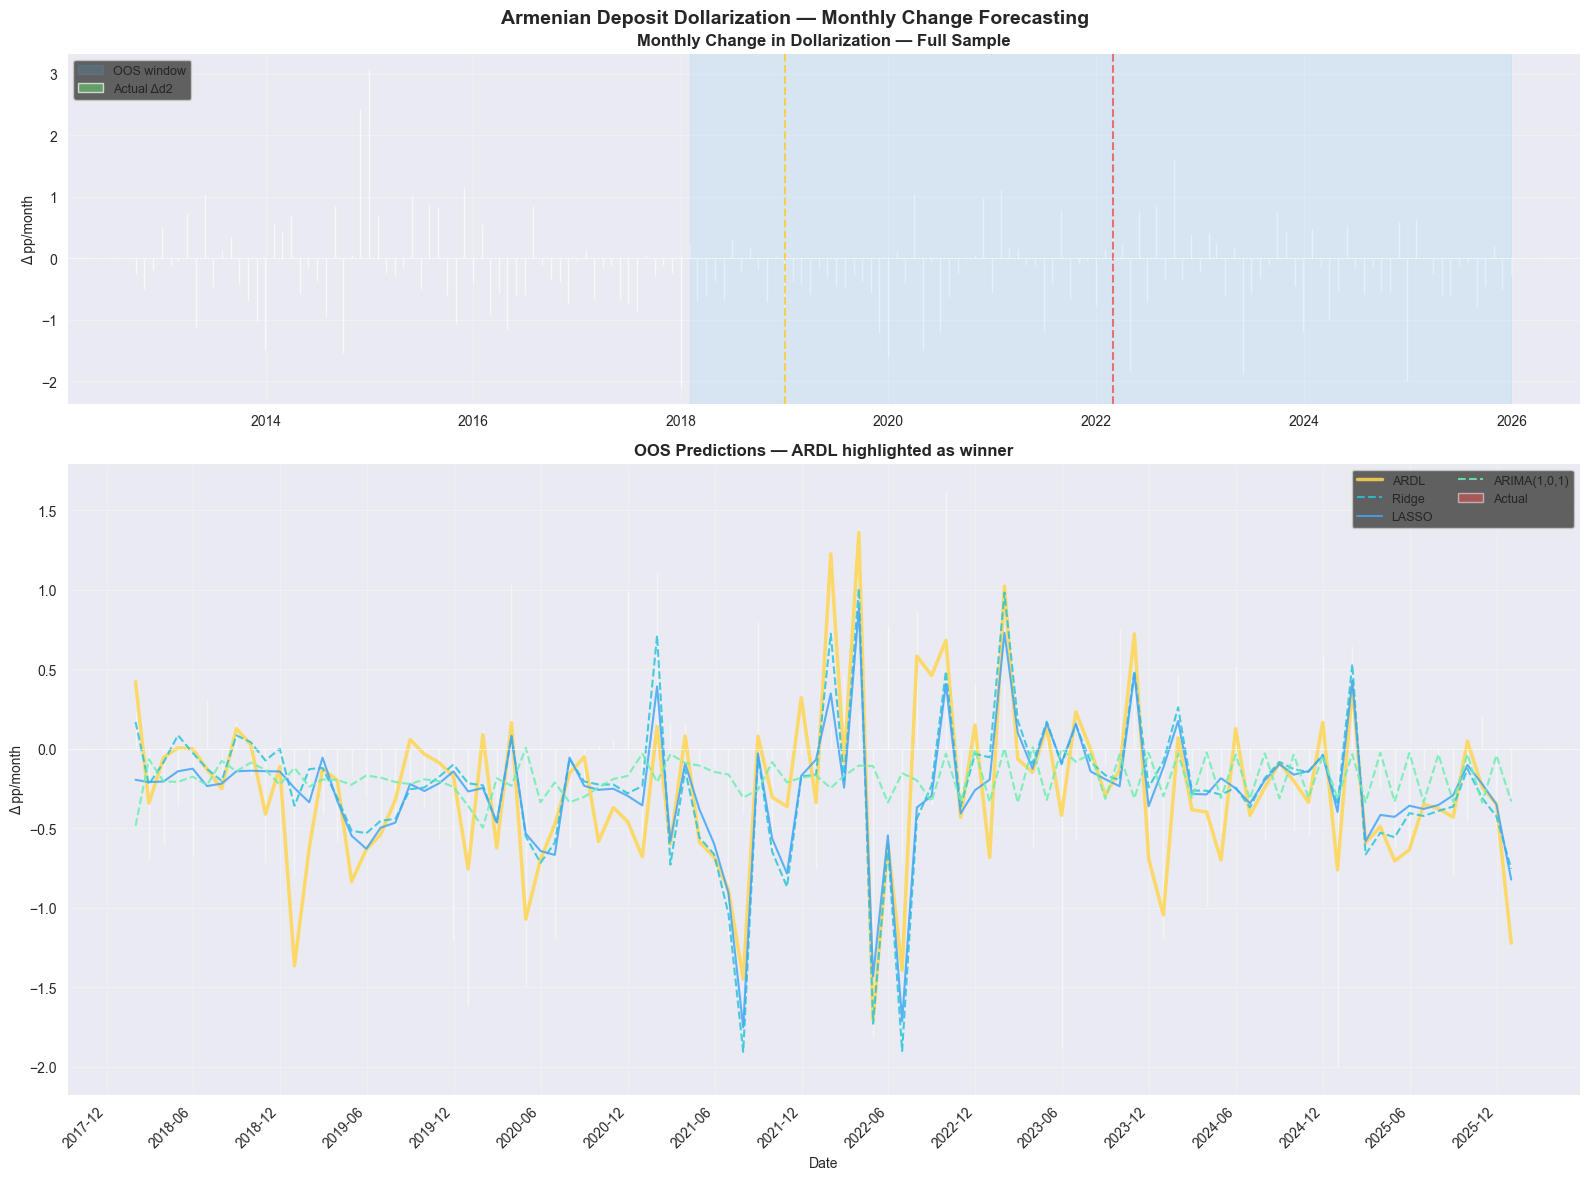

In [30]:
# ── Final forecast plot ───────────────────────────────────────────────────────
dates = df_model['Date'].values
oos_mask = ~np.isnan(lasso_preds)
oos_start_date = dates[oos_mask][0]
oos_date_mask = dates >= oos_start_date

fig, axes = plt.subplots(2, 1, figsize=(16, 12),
                         gridspec_kw={'height_ratios': [1, 1.8]})

# Panel 1: Full delta series
axes[0].bar(dates, y_m,
            color=['#ef5350' if v > 0 else '#66bb6a' for v in y_m],
            alpha=0.7, width=20, label='Actual Δd2')
axes[0].axvspan(oos_start_date, dates[-1], alpha=0.12,
                color='#4fc3f7', label='OOS window')
axes[0].axvline(np.datetime64('2022-03-01'), color='#ef5350',
                linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].axvline(np.datetime64('2019-01-01'), color='#ffca28',
                linewidth=1.5, linestyle='--', alpha=0.8)
axes[0].axhline(0, color='white', linewidth=0.5, linestyle='--')
axes[0].set_title('Monthly Change in Dollarization — Full Sample',
                  fontweight='bold', fontsize=12)
axes[0].set_ylabel('Δ pp/month')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.25)

# Panel 2: OOS predictions — winner highlighted
axes[1].bar(dates[oos_date_mask], y_m[oos_date_mask],
            color=['#ef5350' if v > 0 else '#66bb6a'
                   for v in y_m[oos_date_mask]],
            alpha=0.5, width=20, label='Actual')

model_plots = [
    (winner_name, winner_preds, '#ffd54f', '-', 2.5),
    ('Ridge', ridge_preds, '#26c6da', '--', 1.5),
    ('LASSO', lasso_preds, '#42a5f5', '-', 1.5),
    ('ARIMA(1,0,1)', arima_preds, '#69f0ae', '--', 1.5),]

for name, preds, color, ls, lw in model_plots:
    mask = ~np.isnan(preds) & oos_date_mask
    if mask.sum() == 0: continue
    axes[1].plot(dates[mask], preds[mask], linewidth=lw,
                 color=color, alpha=0.85, linestyle=ls, label=name)

axes[1].axhline(0, color='white', linewidth=0.5, linestyle='--')
axes[1].set_title(f'OOS Predictions — {winner_name} highlighted as winner',
                  fontweight='bold', fontsize=12)
axes[1].set_ylabel('Δ pp/month')
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
axes[1].legend(fontsize=9, ncol=2)
axes[1].grid(True, alpha=0.25)

plt.suptitle('Armenian Deposit Dollarization — Monthly Change Forecasting',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'all_model_predictions_delta.png'),
            dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# ── Save all results ──────────────────────────────────────────────────────────
out_path = os.path.join(OUTPUT_DIR, 'structured_modeling_results.xlsx')

with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    comparison.to_excel(writer, sheet_name='Full_Comparison', index=True)
    # chow_df.to_excel(writer, sheet_name='Chow_Tests')
    dm_df.to_excel(writer, sheet_name=f'DM_{winner_name.replace("/", "_")}_vs_All',
                   index=False)
    boot_df.to_excel(writer, sheet_name='Bootstrap_CI', index=False)
    coef_df.to_excel(writer, sheet_name='LASSO_Coefficients', index=False)

    pred_df = df_model[['Date', TARGET_LEVEL, TARGET]].copy()
    pred_df['Random_Walk'] = rw_preds
    pred_df['ARIMA'] = arima_preds
    pred_df['AR1_Delta'] = ar1_preds
    pred_df['LASSO'] = lasso_preds
    pred_df['Ridge'] = ridge_preds
    pred_df['ElasticNet'] = enet_preds
    pred_df['ARDL'] = ardl_preds
    pred_df.to_excel(writer, sheet_name='All_Predictions', index=False)

    for name, dff in [
        ('LASSO_CV', lasso_cv_df),
        ('Ridge_CV', ridge_cv_df),
        ('ElasticNet_CV', enet_cv_df),
        ('ARDL_CV', ardl_cv_df),
        ('ARIMA_CV', arima_cv_df),
        ('AR1_CV', ar1_cv_df),
        ('RandomWalk_CV', rw_df),
    ]:
        dff.to_excel(writer, sheet_name=name)

print(f'✅ Saved: {out_path}')

✅ Saved: Outputs\structured_modeling_results.xlsx


In [32]:
# ── Final summary ─────────────────────────────────────────────────────────────
print('=' * 65)
print('THESIS RESULTS SUMMARY — DELTA TARGET')
print('Armenian Deposit Dollarization Change Forecasting | 2012-2025')
print('=' * 65)

winner_row = comparison.iloc[0]
rw_row = comparison[comparison['Model'] == 'Random Walk (Zero Change)'].iloc[0]
arima_row = comparison[comparison['Model'] == 'ARIMA(1,0,1)'].iloc[0]

print(f'\n── BEST MODEL: {winner_row["Model"]} ──')
print(f'RMSE          : {winner_row["RMSE"]:.4f} pp/month')
print(f'MAE           : {winner_row["MAE"]:.4f} pp/month')
print(f'Dir. Accuracy : {winner_row["Dir. Accuracy (%)"]:.1f}%  '
      f'(vs 50% random baseline)')
print(f'vs Random Walk: {((rw_row["RMSE"] - winner_row["RMSE"]) / rw_row["RMSE"] * 100):.1f}% RMSE improvement')
print(f'vs ARIMA      : {((arima_row["RMSE"] - winner_row["RMSE"]) / arima_row["RMSE"] * 100):.1f}% RMSE improvement')
print('=' * 65)

THESIS RESULTS SUMMARY — DELTA TARGET
Armenian Deposit Dollarization Change Forecasting | 2012-2025

── BEST MODEL: ARDL ──
RMSE          : 0.5627 pp/month
MAE           : 0.4572 pp/month
Dir. Accuracy : 79.2%  (vs 50% random baseline)
vs Random Walk: 17.6% RMSE improvement
vs ARIMA      : 14.2% RMSE improvement


# Unstructured data modeling

In [33]:
# ── 0. IMPORTS ──────────────────────────────────────────────────────────────
import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib
import pdfplumber
matplotlib.rcParams.update({
    'figure.facecolor': '#1e1e1e', 'axes.facecolor': '#2d2d2d',
    'axes.edgecolor': '#555', 'text.color': 'white',
    'axes.labelcolor': 'white', 'xtick.color': 'white', 'ytick.color': 'white',
    'legend.facecolor': '#3d3d3d', 'grid.color': '#444', 'grid.alpha': 0.4
})
import matplotlib.pyplot as plt
from tqdm import tqdm

warnings.filterwarnings('ignore')
print('Imports OK')

Imports OK


In [34]:
# ── 1. PATHS ─────────────────────────────────────────────────────────────────
os.chdir(r'C:\Users\HP\Zvarth Aleksanyan\Data Science for Business\YSU_DSB_Thesis')

CORPUS_DIR  = 'Analysis/Data/Unstructured'
OUTPUT_PATH = 'Analysis/Outputs/nlp_features.csv'
PLOT_DIR    = 'Analysis/Outputs'

os.makedirs(PLOT_DIR, exist_ok=True)
print(f'Working directory: {os.getcwd()}')
print(f'Corpus:  {CORPUS_DIR}')
print(f'Output:  {OUTPUT_PATH}')

Working directory: C:\Users\HP\Zvarth Aleksanyan\Data Science for Business\YSU_DSB_Thesis
Corpus:  Analysis/Data/Unstructured
Output:  Analysis/Outputs/nlp_features.csv


### Date parsing

In [35]:
from dateutil.relativedelta import relativedelta

# Actual publication dates extracted from PDFs
IR_DATE_LOOKUP_RAW = {
    'IR_2012_Q1.pdf': '2012-02',
    'IR_2012_Q2.pdf': '2012-05',
    'IR_2012_Q3.pdf': '2012-08',
    'IR_2012_Q4.pdf': '2012-11',
    'IR_2013_Q1.pdf': '2013-02',
    'IR_2013_Q2.pdf': '2013-05',
    'IR_2013_Q3.pdf': '2013-08',
    'IR_2013_Q4.pdf': '2013-11',
    'IR_2014_Q1.pdf': '2014-02',
    'IR_2014_Q2.pdf': '2014-05',
    'IR_2014_Q3.pdf': '2014-08',
    'IR_2014_Q4.pdf': '2014-11',
    'IR_2015_Q1.pdf': '2015-02',
    'IR_2015_Q2.pdf': '2015-05',
    'IR_2015_Q3.pdf': '2015-08',
    'IR_2015_Q4.pdf': '2015-11',
    'IR_2016_Q1.pdf': '2016-02',
    'IR_2016_Q2.pdf': '2016-05',
    'IR_2016_Q3.pdf': '2016-08',
    'IR_2016_Q4.pdf': '2016-11',
    'IR_2017_Q1.pdf': '2017-02',
    'IR_2017_Q2.pdf': '2017-05',
    'IR_2017_Q3.pdf': '2017-08',
    'IR_2017_Q4.pdf': '2017-11',
    'IR_2018_Q1.pdf': '2018-02',
    'IR_2018_Q2.pdf': '2018-05',
    'IR_2018_Q3.pdf': '2018-08',
    'IR_2018_Q4.pdf': '2018-11',
    'IR_2019_Q1.pdf': '2019-03',
    'IR_2019_Q2.pdf': '2019-06',
    'IR_2019_Q3.pdf': '2019-09',
    'IR_2019_Q4.pdf': '2019-12',
    'IR_2020_Q1.pdf': '2020-03',
    'IR_2020_Q2.pdf': '2020-06',
    'IR_2020_Q3.pdf': '2020-09',
    'IR_2020_Q4.pdf': '2020-12',
    'IR_2021_Q1.pdf': '2021-03',
    'IR_2021_Q2.pdf': '2021-06',
    'IR_2021_Q3.pdf': '2021-09',
    'IR_2021_Q4.pdf': '2021-12',
    'IR_2022_Q1.pdf': '2022-03',
    'IR_2022_Q2.pdf': '2022-06',
    'IR_2022_Q3.pdf': '2022-09',
    'IR_2022_Q4.pdf': '2022-12',
    'IR_2023_Q1.pdf': '2023-03',
    'IR_2023_Q2.pdf': '2023-06',
    'IR_2023_Q3.pdf': '2023-09',
    'IR_2023_Q4.pdf': '2023-12',
    'IR_2024_Q1.pdf': '2024-03',
    'IR_2024_Q2.pdf': '2024-06',
    'IR_2024_Q3.pdf': '2024-09',
    'IR_2024_Q4.pdf': '2024-12',
    'IR_2025_Q1.pdf': '2025-03',
    'IR_2025_Q2.pdf': '2025-06',
    'IR_2025_Q3.pdf': '2025-09',
    'IR_2025_Q4.pdf': '2025-12',
}

# DIFFUSION_LAG_MONTHS = 0 means: assign score to publication month
# The lag 1 applied in S3 (ir_dollarization_intensity_lag1) handles
# the one-month diffusion delay for household response
# Add 1-month diffusion lag
DIFFUSION_LAG_MONTHS = 0
IR_DATE_LOOKUP = {}
for fname, date_str in IR_DATE_LOOKUP_RAW.items():
    dt = pd.to_datetime(date_str + '-01') + relativedelta(months=DIFFUSION_LAG_MONTHS)
    IR_DATE_LOOKUP[fname] = dt.strftime('%Y-%m')

def parse_date_key(filename):
    name = os.path.splitext(filename)[0].upper()

    # IR — Inflation Reports (exact lookup + diffusion lag)
    if filename in IR_DATE_LOOKUP:
        return IR_DATE_LOOKUP[filename], 'IR'

    # FSR — Financial Stability Reports
    m = re.search(r'FSR_(\d{4})', name)
    if m:
        coverage_year = int(m.group(1))
        pub_year = coverage_year + 1
        return f'{pub_year}-04', 'FSR'

    # MIN — Board Minutes and Transparency Reports
    m = re.search(r'MIN_(\d{4})_(\d{2})', name)
    if m:
        year, month = m.group(1), m.group(2)
        return f'{year}-{month}', 'MIN'
    return None, None

### Text extraction

In [36]:
def extract_full_text(pdf_path):
    text = ''
    try:
        with pdfplumber.open(pdf_path) as pdf:
            for page in pdf.pages:
                page_text = page.extract_text()
                if page_text:
                    text += page_text + '\n'
    except Exception as e:
        print(f'  [ERROR] {os.path.basename(pdf_path)}: {e}')
    return text

print('Text extractor ready.')


Text extractor ready.


#### Section filtering

In [37]:

FX_KEYWORDS = [
    'dollarization', 'dedollarization', 'de-dollarization',
    'foreign currency', 'fx deposit', 'fx loan',
    'dram', 'amd', 'exchange rate', 'usd', 'ruble',
    'deposit', 'refinancing rate', 'reserve requirement',
    'currency', 'monetary policy', 'inflation', 'lending',
    'uncertainty', 'risk', 'depreciation', 'appreciation',
    'remittance', 'capital outflow', 'financial stability',
    'case a', 'case b', 'baseline scenario',
    'confidence band', 'policy rate', 'board',
    'vote', 'unchanged', 'reduced by', 'increased by',
    'output gap', 'neutral rate', 'risk premium',
]


def filter_sections(text, doc_type, min_line_length=35):
    if not text:
        return '', True

    lines = text.split('\n')
    all_lines = [l.strip() for l in lines if len(l.strip()) >= min_line_length]

    relevant = [l for l in all_lines
                if any(kw in l.lower() for kw in FX_KEYWORDS)]

    used_fallback = False
    if len(relevant) < 5:
        relevant = all_lines[:150]
        used_fallback = True

    max_lines = {'IR': 500, 'FSR': 600, 'MIN': 200, 'PR': 100}
    cap = max_lines.get(doc_type, 200)
    relevant = relevant[:cap]

    return (' '.join(relevant) if relevant else ''), used_fallback

In [38]:
# ── 5. CBA TONE SCORER ──────────────────────────────────────────────────────

CONCERN_TERMS = [
    'risk', 'risks', 'risky', 'vulnerability', 'vulnerab',
    'deteriorat', 'adverse', 'downside', 'worsen', 'weaken',
    'slowdown', 'contraction', 'decline',
    'pressure', 'tension', 'stress', 'tighten',
    'shock', 'disruption', 'spillover', 'volatile', 'volatility',
    'fluctuat', 'instabilit', 'uncertainty', 'uncertain',
    'crisis', 'distress', 'turmoil', 'threat',
    'depreciation', 'capital outflow', 'dollarization risk',
    'high level of dollarization', 'fx exposure',
    'sanction', 'geopolit', 'conflict', 'devaluat', 'ruble deprec',
    'downside risk', 'prevail', 'exceed target', 'below target',
]

REASSURANCE_TERMS = [
    'stable', 'stability', 'stabiliz', 'robust', 'resilient',
    'sound', 'solid', 'adequate', 'sufficient',
    'improved', 'improvement', 'strengthened', 'increased confidence',
    'recovery', 'recover', 'rebound',
    'manageable', 'within regulatory', 'maintained', 'preserved',
    'remained stable', 'no violation', 'complied',
    'de-dollarization', 'dedollarization', 'reduced dollarization',
    'decline in dollarization', 'decrease in foreign currency',
    'expansionary', 'accommodative', 'supportive', 'stimulus',
    'growth', 'positive', 'favorable', 'balanced risk',
    'within confidence band', 'close to target', 'dollarization decreased', 'dollarization reduced', 'fx deposits decreased',
]

INFLATION_CONCERN_TERMS = [
    'inflation above target', 'inflationary pressure', 'price instability',
    'inflation expectations unanchored', 'inflation risks', 'exceeds target',
    'above the upper band', 'inflation acceleration',
]

INFLATION_REASSURANCE_TERMS = [
    'inflation within target', 'within confidence band', 'close to target',
    'inflation expectations anchored', 'price stability maintained',
    'inflation decelerated', 'inflation declined',
]

def inflation_signal(text):
    """
    Separate inflation-specific tone signal.
    Positive = CBA reassured about inflation
    Negative = CBA concerned about inflation
    Kept separate from fx/dollarization tone to avoid conflation.
    """
    if not text or len(text.strip()) < 20:
        return 0.0
    text_lower = text.lower()
    n_words = len(text_lower.split())
    if n_words == 0:
        return 0.0
    concern  = sum(1 for t in INFLATION_CONCERN_TERMS  if t in text_lower)
    reassure = sum(1 for t in INFLATION_REASSURANCE_TERMS if t in text_lower)
    return round((reassure - concern) / n_words * 1000, 6)

# Sanity check
infl_bad  = 'Inflation remains above the upper confidence band. Inflationary pressures persist.'
infl_good = 'Inflation is within the target band. Price stability maintained.'
print(f'Inflation signal (bad):  {inflation_signal(infl_bad):.4f}')
print(f'Inflation signal (good): {inflation_signal(infl_good):.4f}')

def cba_tone_score(text):
    """
    CBA tone score: (reassurance - concern) / total_words.
    Single-word terms: whole-word regex on each word.
    Multi-word terms: counted once in full text.
    2-word negation window applied for single-word terms.
    """
    if not text or len(text.strip()) < 20:
        return 0.0
    text_lower = text.lower()
    words      = text_lower.split()
    n_words    = len(words)
    if n_words == 0:
        return 0.0

    negation = {'no', 'not', 'without', 'neither', 'never'}
    concern  = 0
    reassure = 0

    # Single-word terms — check per word with negation window
    single_concern   = [t for t in CONCERN_TERMS   if ' ' not in t]
    single_reassure  = [t for t in REASSURANCE_TERMS if ' ' not in t]
    multi_concern    = [t for t in CONCERN_TERMS   if ' ' in t]
    multi_reassure   = [t for t in REASSURANCE_TERMS if ' ' in t]

    for i, word in enumerate(words):
        window = set(words[max(0, i-2):i])
        neg    = bool(window & negation)
        for term in single_concern:
            if word == term or word.startswith(term):
                if not neg:
                    concern += 1
                break
        for term in single_reassure:
            if word == term or word.startswith(term):
                if not neg:
                    reassure += 1
                break

    # Multi-word terms — count once in full text
    for term in multi_concern:
        concern  += text_lower.count(term)
    for term in multi_reassure:
        reassure += text_lower.count(term)

    return round((reassure - concern) / n_words, 6)

# ── CBA tone sanity check ─────────────────────────────────────────────────────
_concern_text  = ('High risks of dollarization. Volatility increased. '
                  'Uncertainty remains. Crisis conditions deteriorating. '
                  'Adverse downside shock.')
_reassure_text = ('Stability maintained. Dollarization declined. '
                  'Resilient banking sector. Growth improved. '
                  'Sound and adequate buffers.')
_neutral_text  = ('The board met on Tuesday. The report was published. '
                  'The committee reviewed the document.')

print('CBA tone scorer sanity check:')
print(f'  Concern text     : {cba_tone_score(_concern_text):.4f}  (should be negative)')
print(f'  Reassurance text : {cba_tone_score(_reassure_text):.4f}  (should be positive)')
print(f'  Neutral text     : {cba_tone_score(_neutral_text):.4f}  (should be near zero)')

Inflation signal (bad):  -100.0000
Inflation signal (good): 111.1111
CBA tone scorer sanity check:
  Concern text     : -0.5714  (should be negative)
  Reassurance text : 0.4615  (should be positive)
  Neutral text     : 0.0000  (should be near zero)


In [39]:
AMD_APPRECIATION_TERMS = [
    'dram appreciated', 'dram appreciation', 'amd appreciated',
    'appreciation of the dram', 'appreciation of the armenian dram',
    'dram strengthened', 'local currency appreciated',
    'nominal exchange rate appreciated', 'real exchange rate appreciated',
    'dram appreciation trend', 'significant appreciation',
    'appreciating trend', 'dram has appreciated',
]

AMD_DEPRECIATION_TERMS = [
    'dram depreciated', 'dram depreciation', 'dram weakened',
    'depreciation of the dram', 'depreciation pressure',
    'exchange rate depreciation', 'dram under pressure',
    'ruble depreciation', 'currency depreciation risk',
]

def amd_appreciation_signal(text):
    """
    Captures CBA communication about AMD exchange rate direction.
    Positive = CBA describes AMD appreciation (→ dedollarization pressure)
    Negative = CBA describes AMD depreciation (→ dollarization pressure)
    This signal is present even when CBA does not discuss dollarization
    directly, capturing the transmission mechanism implicitly.
    """
    if not text or len(text.strip()) < 20:
        return 0.0
    text_lower = text.lower()
    n_words = len(text_lower.split())
    if n_words == 0:
        return 0.0
    appreci = sum(1 for t in AMD_APPRECIATION_TERMS if t in text_lower)
    depreci = sum(1 for t in AMD_DEPRECIATION_TERMS if t in text_lower)
    return round((appreci - depreci) / n_words * 1000, 6)

# Sanity check
amd_appreci_text = ('The dram appreciated significantly. Dram appreciation trend '
                    'continued. Significant appreciation of the Armenian dram was observed.')
amd_depreci_text = ('Dram depreciation pressure increased. Depreciation of the dram '
                    'continued amid ruble depreciation.')
amd_neutral = ('The Board reviewed inflation developments in February.')

print('AMD signal sanity check:')
print(f'  Appreciation text: {amd_appreciation_signal(amd_appreci_text):.4f}  (should be positive)')
print(f'  Depreciation text: {amd_appreciation_signal(amd_depreci_text):.4f}  (should be negative)')
print(f'  Neutral text:      {amd_appreciation_signal(amd_neutral):.4f}  (should be zero)')

AMD signal sanity check:
  Appreciation text: 312.5000  (should be positive)
  Depreciation text: -333.3333  (should be negative)
  Neutral text:      0.0000  (should be zero)


In [40]:
# ── 6. DOLLARIZATION INTENSITY SCORER ───────────────────────────────────────

DOLLARIZATION_TERMS = [
    # Keep ONLY highly specific terms
    'dollarization', 'dedollarization', 'de-dollarization',
    'currency substitution',
    'foreign currency deposit', 'fx deposit',
    'foreign currency loan', 'fx loan',
    'dram deposit', 'amd deposit',
    'dram-denominated', 'amd-denominated',
    'fx exposure', 'currency mismatch',
    'deposit dollarization', 'loan dollarization',
    'dram appreciation', 'dram depreciation',
    'currency structure', 'foreign exchange deposit',
    'usd/amd', 'ruble depreciation',
    'dramization', 'precautionary savings',
    'unhedged borrowers', 'rr spread',
]

def dollarization_intensity(text):
    if not text or len(text.strip()) < 20:
        return 0.0
    text_lower = text.lower()
    n_words    = len(text_lower.split())
    if n_words == 0:
        return 0.0
    count = 0
    for term in DOLLARIZATION_TERMS:
        pattern = r'\b' + re.escape(term) + r'\b'
        count  += len(re.findall(pattern, text_lower))
    return round(count / n_words * 1000, 6)

high_dol_text = 'Dollarization remained high. Foreign currency deposits constitute 71% of total deposits. The share of fx loans declined. De-dollarization efforts continued.'
low_dol_text  = 'The Board decided to leave the refinancing rate unchanged. Inflation remained within the confidence band. Economic growth continued.'

print('Dollarization intensity sanity check:')
print(f'  High dollarization text:  {dollarization_intensity(high_dol_text):.4f} per 1000 words')
print(f'  Low dollarization text:   {dollarization_intensity(low_dol_text):.4f} per 1000 words')

Dollarization intensity sanity check:
  High dollarization text:  150.0000 per 1000 words
  Low dollarization text:   0.0000 per 1000 words


In [41]:
# ── 7b. FORWARD-LOOKING RATIO SCORER ────────────────────────────────────────

FORWARD_LOOKING_MARKERS = [
    'will', 'would', 'forecast', 'projected', 'expected',
    'anticipat', 'outlook', 'going forward', 'in the coming',
    'medium-term', 'next quarter', 'future', 'likely to',
    'is expected', 'are expected', 'projection', 'target',
]

def forward_looking_ratio(text):
    """
    Ratio of forward-looking sentences to total sentences.
    Higher = CBA is more focused on future conditions.
    Captures predictive signal beyond backward-looking tone.
    """
    if not text or len(text.strip()) < 20:
        return 0.0
    sentences = re.split(r'[.!?]', text.lower())
    if not sentences:
        return 0.0
    forward = sum(1 for s in sentences
                  if any(m in s for m in FORWARD_LOOKING_MARKERS))
    return round(forward / max(len(sentences), 1), 6)

# Sanity check
fwd_text  = 'The Board expects inflation to remain within the target band. Growth is projected to accelerate. Risks to the outlook are balanced.'
back_text = 'Inflation declined last quarter. The exchange rate depreciated in the previous period. GDP growth slowed.'

print('Forward-looking ratio sanity check:')
print(f'  Forward-looking text:  {forward_looking_ratio(fwd_text):.4f}  (should be high)')
print(f'  Backward-looking text: {forward_looking_ratio(back_text):.4f}  (should be low)')

# ── Economic interpretation of all NLP features ───────────────────────────────
print("""
=== ECONOMIC INTERPRETATION OF NLP FEATURES ===

cba_tone
  → Net policy stance signal: hawkish (negative) vs dovish (positive).
  → Captures CBA's implicit assessment of financial stability conditions.
  → Negative tone associated with tightening signals and FX intervention.
  → Formula: (reassurance_terms - concern_terms) / total_words

dollarization_intensity
  → Attention signal: higher = more CBA focus on FX and dollarization risk.
  → Elevated attention typically precedes policy responses to FX imbalances.
  → Formula: dollarization_term_count / total_words × 1000

forward_looking_ratio
  → Expectation signal: share of forward-looking sentences in document.
  → Higher = CBA communicating about future conditions, not past outcomes.
  → Most predictive for household currency choice expectations.
  → Formula: forward_looking_sentences / total_sentences

Note: policy_uncertainty excluded — lexicon overlaps with cba_tone
concern dimension. All three retained features capture distinct
economic dimensions with minimal information overlap.
""")

Forward-looking ratio sanity check:
  Forward-looking text:  0.7500  (should be high)
  Backward-looking text: 0.0000  (should be low)

=== ECONOMIC INTERPRETATION OF NLP FEATURES ===

cba_tone
  → Net policy stance signal: hawkish (negative) vs dovish (positive).
  → Captures CBA's implicit assessment of financial stability conditions.
  → Negative tone associated with tightening signals and FX intervention.
  → Formula: (reassurance_terms - concern_terms) / total_words

dollarization_intensity
  → Attention signal: higher = more CBA focus on FX and dollarization risk.
  → Elevated attention typically precedes policy responses to FX imbalances.
  → Formula: dollarization_term_count / total_words × 1000

forward_looking_ratio
  → Expectation signal: share of forward-looking sentences in document.
  → Higher = CBA communicating about future conditions, not past outcomes.
  → Most predictive for household currency choice expectations.
  → Formula: forward_looking_sentences / total_senten

## Cell 8 — Score All Documents

IR and FSR scored separately.
Three features per document: cba_tone, dollarization_intensity, forward_looking_ratio.
Note: policy_uncertainty excluded — see design principles.

In [42]:
# ── 8. SCORE ALL DOCUMENTS ──────────────────────────────────────────────────
# Five scorers applied to all document types (IR, FSR, MIN)
# FSR and MIN scored for documentation and transparency;
# only IR-based features survive into the final S3 model
NLP_COLS = [
    'cba_tone',
    'dollarization_intensity',
    'forward_looking_ratio',
    'inflation_signal',
    'amd_appreciation_signal',
]
pdf_files = sorted([f for f in os.listdir(CORPUS_DIR) if f.lower().endswith('.pdf')])
print(f'Found {len(pdf_files)} PDF files in corpus.\n')

records = []
skipped = []

print('── Stage 1: Extract & filter text ──')
for fname in tqdm(pdf_files):
    date_key, doc_type = parse_date_key(fname)
    if date_key is None:
        skipped.append(fname)
        continue

    full_path     = os.path.join(CORPUS_DIR, fname)
    raw_text      = extract_full_text(full_path)
    if not raw_text:
        raw_text = ''

    filtered_text, used_fallback = filter_sections(raw_text, doc_type)
    if not filtered_text:
        filtered_text = ''
        print(f'  ⚠️  Empty filtered text: {fname}')

    records.append({
        'filename':        fname,
        'date_key':        date_key,
        'doc_type':        doc_type,
        'text':            filtered_text,
        'raw_word_count':  len(raw_text.split()),
        'filt_word_count': len(filtered_text.split()),
        'used_fallback':   used_fallback,
    })

if skipped:
    print(f'\n⚠️  Skipped (unrecognised filename):')
    for f in skipped:
        print(f'   {f}')

n_ir  = sum(1 for r in records if r['doc_type'] == 'IR')
n_fsr = sum(1 for r in records if r['doc_type'] == 'FSR')
n_min = sum(1 for r in records if r['doc_type'] == 'MIN')
print(f'\nExtracted: {len(records)} documents ({n_ir} IR, {n_fsr} FSR, {n_min} MIN)')

print('\n── Stage 2: Score documents ──')
results = []
for record in tqdm(records):
    if record['filt_word_count'] < 50:
        print(f"  ⚠️  Very short filtered text: {record['filename']} "
              f"({record['filt_word_count']} words)")

    text    = record['text']
    tone    = cba_tone_score(text)
    dol_int = dollarization_intensity(text)
    fwd     = forward_looking_ratio(text)
    infl = inflation_signal(text)
    amd     = amd_appreciation_signal(text)


    if record['used_fallback'] and record['doc_type'] == 'MIN':
        if dol_int == 0:
            dol_int = np.nan
        if tone == 0:
            tone = np.nan

    results.append({
        'date_key':                record['date_key'],
        'filename':                record['filename'],
        'doc_type':                record['doc_type'],
        'cba_tone':                tone,
        'dollarization_intensity': dol_int,
        'forward_looking_ratio':   fwd,
        'raw_words':               record['raw_word_count'],
        'filtered_words':          record['filt_word_count'],
        'inflation_signal': infl,
        'amd_appreciation_signal': amd,

    })

df_scores = pd.DataFrame(results)
df_scores['Date'] = pd.to_datetime(df_scores['date_key'])
df_scores = df_scores.sort_values('Date').reset_index(drop=True)

print('\n── Score summary by document type ──')
print(df_scores.groupby('doc_type')[
    ['cba_tone', 'dollarization_intensity', 'forward_looking_ratio']
].describe().round(4))

display_cols = ['date_key', 'doc_type', 'filename', 'cba_tone',
                'dollarization_intensity', 'forward_looking_ratio',
                'filtered_words']
print('\nPer-document scores (sorted by date):')
display(df_scores[display_cols].to_string(index=False))

Found 167 PDF files in corpus.

── Stage 1: Extract & filter text ──


100%|██████████| 167/167 [43:08<00:00, 15.50s/it]  



Extracted: 167 documents (56 IR, 14 FSR, 97 MIN)

── Stage 2: Score documents ──


100%|██████████| 167/167 [00:07<00:00, 23.83it/s]


── Score summary by document type ──
         cba_tone                                                          \
            count    mean     std     min     25%     50%     75%     max   
doc_type                                                                    
FSR          14.0 -0.0286  0.0069 -0.0411 -0.0332 -0.0271 -0.0231 -0.0175   
IR           56.0 -0.0141  0.0114 -0.0395 -0.0205 -0.0136 -0.0065  0.0102   
MIN          97.0 -0.0098  0.0166 -0.0486 -0.0148 -0.0058  0.0013  0.0201   

         dollarization_intensity          ...                  \
                           count    mean  ...     75%     max   
doc_type                                  ...                   
FSR                         14.0  1.4713  ...  2.2165  2.7850   
IR                          56.0  1.0510  ...  1.3568  2.6617   
MIN                         97.0  0.6230  ...  1.0811  4.8154   

         forward_looking_ratio                                          \
                         count    

'date_key doc_type        filename  cba_tone  dollarization_intensity  forward_looking_ratio  filtered_words\n 2012-02      MIN MIN_2012_02.pdf -0.002203                 2.202643               0.023256             454\n 2012-02       IR  IR_2012_Q1.pdf -0.016695                 2.140411               0.244604            2336\n 2012-03      MIN MIN_2012_03.pdf  0.000000                 2.150538               0.093750             465\n 2012-04      MIN MIN_2012_04.pdf  0.001305                 1.305483               0.105263             766\n 2012-04      FSR    FSR_2011.pdf -0.026109                 0.636807               0.000967            4711\n 2012-05      MIN MIN_2012_05.pdf  0.000000                 1.572327               0.129630             636\n 2012-05       IR  IR_2012_Q2.pdf -0.011897                 1.220256               0.060714            3278\n 2012-07      MIN MIN_2012_07.pdf  0.000000                 4.184100               0.057143             478\n 2012-08      MIN 

In [43]:
# ── Document audit table ──────────────────────────────────────────────────────
print('=== DOCUMENT AUDIT TABLE ===')
audit = df_scores[['date_key', 'doc_type', 'filename',
                    'raw_words', 'filtered_words']].copy()
audit['extraction_rate'] = (audit['filtered_words'] /
                            audit['raw_words'].replace(0, np.nan)).round(3)
audit['short_flag'] = audit['filtered_words'] < 100
audit['suspiciously_short'] = audit['raw_words'] < 500

print(f'\nTotal documents: {len(audit)}')
print(f'Short filtered text (<100 words): {audit["short_flag"].sum()}')
print(f'Suspiciously short raw (<500 words): {audit["suspiciously_short"].sum()}')
print(f'\nBy document type:')
print(audit.groupby('doc_type').agg(
    count=('filename', 'count'),
    avg_raw_words=('raw_words', 'mean'),
    avg_filtered_words=('filtered_words', 'mean'),
    avg_extraction_rate=('extraction_rate', 'mean'),
    n_short=('short_flag', 'sum')
).round(1).to_string())

print('\nEarliest and latest by document type:')
for dt in ['IR', 'FSR', 'MIN']:
    subset = audit[audit['doc_type'] == dt]
    if len(subset) > 0:
        print(f'  {dt}: {subset["date_key"].min()} → {subset["date_key"].max()}')

# Flag any suspicious documents
flagged = audit[audit['short_flag'] | audit['suspiciously_short']]
if len(flagged) > 0:
    print(f'\n⚠️  Flagged documents ({len(flagged)}):')
    display(flagged[['date_key', 'doc_type', 'filename',
                      'raw_words', 'filtered_words']].to_string(index=False))
else:
    print('\n✅ No suspicious documents found')

=== DOCUMENT AUDIT TABLE ===

Total documents: 167
Short filtered text (<100 words): 0
Suspiciously short raw (<500 words): 0

By document type:
          count  avg_raw_words  avg_filtered_words  avg_extraction_rate  n_short
doc_type                                                                        
FSR          14        26881.0              5468.7                  0.2        0
IR           56        17065.3              4068.4                  0.2        0
MIN          97         1749.1               982.1                  0.5        0

Earliest and latest by document type:
  IR: 2012-02 → 2025-12
  FSR: 2012-04 → 2025-04
  MIN: 2012-02 → 2025-12

✅ No suspicious documents found


## Cell 9 — Temporal Alignment

Forward-fill capped at 4 months to prevent stale signal propagation.
IR and FSR features kept separate throughout alignment.


In [44]:
# ── 9. TEMPORAL ALIGNMENT ───────────────────────────────────────────────────

# Forward-fill justification:
# IR published quarterly — forward-filled 4 months: CBA policy stance
#   communicated in IR remains active until next report; households respond
#   with delay. 4-month cap prevents stale signal propagation.
# MIN forward-filled 2 months: Board decisions active until next meeting
#   (6-8 week cycle). Beyond 2 months a new decision supersedes previous.
# Delta features zeroed in non-publication months — only fire when a new
#   document actually arrives, preventing carry-forward from being treated
#   as new information.

df_ir  = df_scores[df_scores['doc_type'] == 'IR'].copy()
df_fsr = df_scores[df_scores['doc_type'] == 'FSR'].copy()
df_min = df_scores[df_scores['doc_type'] == 'MIN'].copy()

df_ir_agg  = df_ir.groupby('Date')[NLP_COLS].mean().reset_index()
df_fsr_agg = df_fsr.groupby('Date')[NLP_COLS].mean().reset_index()
df_min_agg = (df_min.groupby('Date')[NLP_COLS].mean().reset_index()
              if len(df_min) > 0
              else pd.DataFrame(columns=['Date'] + NLP_COLS))

df_ir_agg  = df_ir_agg.rename(columns={c: f'ir_{c}'  for c in NLP_COLS})
df_fsr_agg = df_fsr_agg.rename(columns={c: f'fsr_{c}' for c in NLP_COLS})
df_min_agg = df_min_agg.rename(columns={c: f'min_{c}' for c in NLP_COLS})

date_range = pd.date_range(start='2012-01-01', end='2025-12-01', freq='MS')
df_monthly = pd.DataFrame({'Date': date_range})

df_monthly = df_monthly.merge(df_ir_agg,  on='Date', how='left')
df_monthly = df_monthly.merge(df_fsr_agg, on='Date', how='left')
df_monthly = df_monthly.merge(df_min_agg, on='Date', how='left')

ir_cols  = [c for c in df_monthly.columns if c.startswith('ir_')]
fsr_cols = [c for c in df_monthly.columns if c.startswith('fsr_')]
min_cols = [c for c in df_monthly.columns if c.startswith('min_')]

# Forward-fill per document type frequency
df_monthly[ir_cols]  = df_monthly[ir_cols].ffill(limit=3)   # quarterly
df_monthly[fsr_cols] = df_monthly[fsr_cols].ffill(limit=12) # annual
df_monthly[min_cols] = df_monthly[min_cols].ffill(limit=2)  # every 6-8 weeks

# Tone deltas — change between consecutive reports
df_monthly['ir_tone_delta']    = df_monthly['ir_cba_tone'].diff()
df_monthly['ir_dol_int_delta'] = df_monthly['ir_dollarization_intensity'].diff()
df_monthly['min_tone_delta']   = df_monthly['min_cba_tone'].diff()
df_monthly['fsr_dol_int_delta']= df_monthly['fsr_dollarization_intensity'].diff()

# Zero out deltas in months where value was just carried forward
for prefix, src_cols in [('ir_', ir_cols), ('fsr_', fsr_cols), ('min_', min_cols)]:
    raw_merge = df_monthly.merge(
        df_scores[df_scores['doc_type'] == prefix.replace('_', '').upper()
                  ][['Date']].drop_duplicates(),
        on='Date', how='left', indicator=True
    )
    no_new_report = raw_merge['_merge'] == 'left_only'
    delta_cols = [c for c in df_monthly.columns
                  if c.startswith(prefix) and c.endswith('_delta')]
    for c in delta_cols:
        df_monthly.loc[no_new_report.values, c] = 0.0

all_delta_cols   = [c for c in df_monthly.columns if c.endswith('_delta')]
all_feature_cols = ir_cols + fsr_cols + min_cols + all_delta_cols

# All lags in one place — do not split across cells
for col in ['ir_dollarization_intensity', 'ir_cba_tone',
            'min_cba_tone', 'ir_forward_looking_ratio',
            'fsr_amd_appreciation_signal', 'min_amd_appreciation_signal']:
    if col in df_monthly.columns:
        df_monthly[f'{col}_lag1'] = df_monthly[col].shift(1)

df_monthly['ir_dol_int_delta_lag1'] = df_monthly['ir_dol_int_delta'].shift(1)
df_monthly['min_tone_delta_lag1'] = df_monthly['min_tone_delta'].shift(1)

# ── Coverage audit ────────────────────────────────────────────────────────────
print('Coverage after forward-fill:')
for col in all_feature_cols:
    n_obs = df_monthly[col].notna().sum()
    pct   = n_obs / len(df_monthly) * 100
    print(f'  {col:<45} {n_obs:3d} / {len(df_monthly)} months ({pct:.0f}%)')

ir_coverage  = df_monthly[ir_cols].notna().mean().mean()  * 100
fsr_coverage = df_monthly[fsr_cols].notna().mean().mean() * 100
min_coverage = (df_monthly[min_cols].notna().mean().mean() * 100
                if min_cols else 0)

print(f'\nIR  coverage : {ir_coverage:.1f}%')
print(f'FSR coverage : {fsr_coverage:.1f}%')
print(f'MIN coverage : {min_coverage:.1f}%')

# Coverage thresholds — justified by minimum signal density for modelling
# FSR: annual publication, <50% coverage means fewer than 6 years of data
# MIN: bimonthly, <30% coverage means fewer than 4 years of data
DROP_FSR = fsr_coverage < 50
DROP_MIN = min_coverage < 30

if DROP_FSR:
    print('ℹ️  FSR dropped — insufficient coverage')
if DROP_MIN:
    print('ℹ️  MIN dropped — insufficient coverage')

df_monthly_temp = df_monthly.dropna(subset=all_feature_cols, how='all')
print(f'\nMonthly observations with at least one NLP feature: {len(df_monthly_temp)}')
print(f'Date range: {df_monthly_temp.Date.min().date()} → '
      f'{df_monthly_temp.Date.max().date()}')

Coverage after forward-fill:
  ir_cba_tone                                   167 / 168 months (99%)
  ir_dollarization_intensity                    167 / 168 months (99%)
  ir_forward_looking_ratio                      167 / 168 months (99%)
  ir_inflation_signal                           167 / 168 months (99%)
  ir_amd_appreciation_signal                    167 / 168 months (99%)
  fsr_cba_tone                                  165 / 168 months (98%)
  fsr_dollarization_intensity                   165 / 168 months (98%)
  fsr_forward_looking_ratio                     165 / 168 months (98%)
  fsr_inflation_signal                          165 / 168 months (98%)
  fsr_amd_appreciation_signal                   165 / 168 months (98%)
  min_cba_tone                                  167 / 168 months (99%)
  min_dollarization_intensity                   167 / 168 months (99%)
  min_forward_looking_ratio                     167 / 168 months (99%)
  min_inflation_signal                          

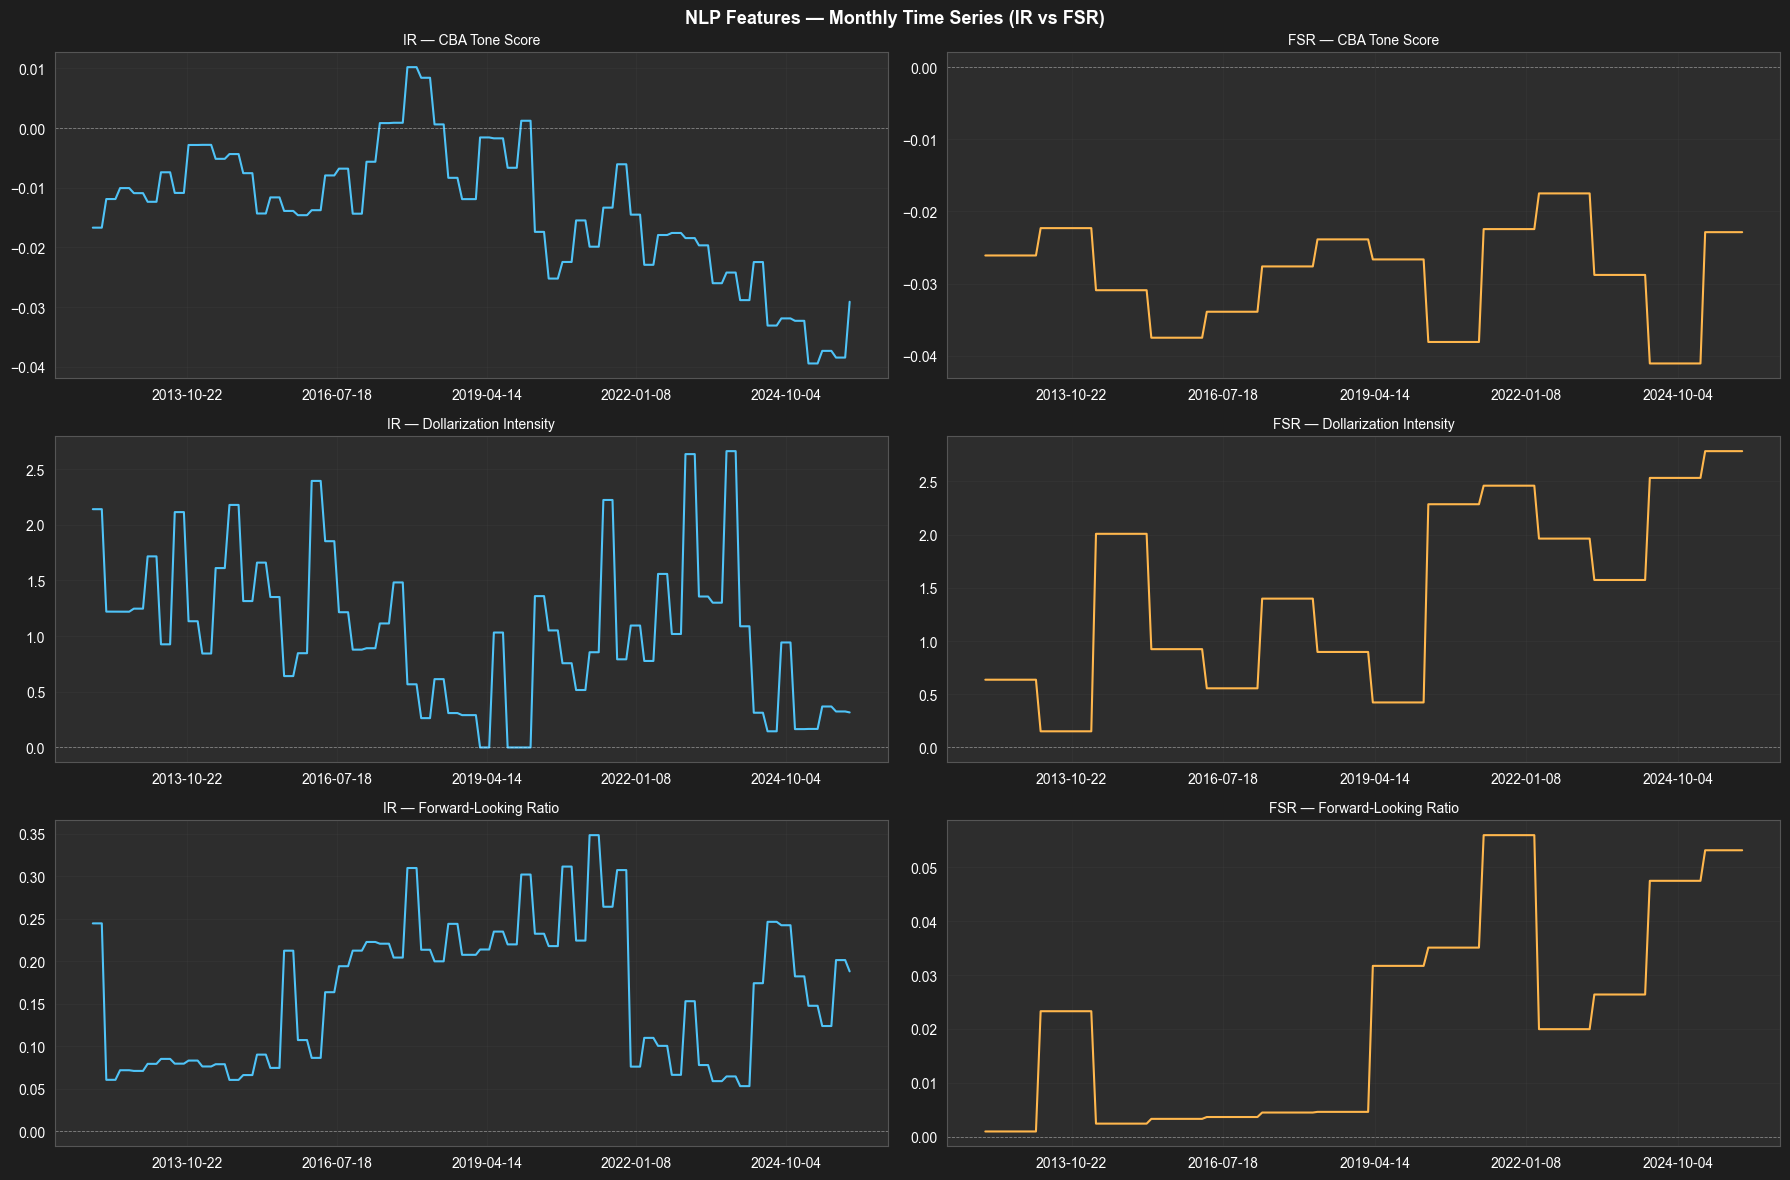

Time series plot saved.


In [45]:
# ── 10a. Feature time series plots ──────────────────────────────────────────
fig, axes = plt.subplots(3, 2, figsize=(18, 12))
fig.suptitle('NLP Features — Monthly Time Series (IR vs FSR)', fontweight='bold', fontsize=13)

plot_pairs = [
    ('ir_cba_tone',                'fsr_cba_tone',                '#4fc3f7', '#ffb74d', 'CBA Tone Score'),
    ('ir_dollarization_intensity', 'fsr_dollarization_intensity', '#4fc3f7', '#ffb74d', 'Dollarization Intensity'),
    ('ir_forward_looking_ratio',   'fsr_forward_looking_ratio',   '#4fc3f7', '#ffb74d', 'Forward-Looking Ratio'),
]

for row, (ir_col, fsr_col, ir_color, fsr_color, title) in enumerate(plot_pairs):
    for col_idx, (col_name, color, label) in enumerate([
        (ir_col,  ir_color,  'IR'),
        (fsr_col, fsr_color, 'FSR'),
    ]):
        ax = axes[row, col_idx]
        if col_name in df_monthly.columns:
            ax.plot(df_monthly['Date'], df_monthly[col_name],
                    color=color, linewidth=1.5, label=label)
            ax.axhline(0, color='white', linewidth=0.6, linestyle='--', alpha=0.4)
        ax.set_title(f'{label} — {title}', fontsize=10)
        ax.grid(True, alpha=0.25)
        ax.xaxis.set_major_locator(plt.MaxNLocator(6))

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, 'nlp_features_v3_timeseries.png'), dpi=150, bbox_inches='tight')
plt.show()
print('Time series plot saved.')


In [46]:
#10b
DB_PATH = r'Analysis\Data\Structured\Database_CBA_Rates and indicators.xlsx'
df_struct = pd.read_excel(DB_PATH)
df_struct.columns = (df_struct.columns.str.strip().str.lower()
                     .str.replace(' ', '_')
                     .str.replace(r'[^a-z0-9_]', '', regex=True))
date_col = [c for c in df_struct.columns if 'date' in c][0]
df_struct['Date'] = pd.to_datetime(df_struct[date_col])
df_struct['Date'] = df_struct['Date'].dt.to_period('M').dt.to_timestamp()

# Update df_monthly_clean first so lags are included in all merges
df_monthly_clean = df_monthly.dropna(
    subset=all_feature_cols, how='all'
).reset_index(drop=True)

df_merged = df_monthly_clean.merge(
    df_struct[['Date', 'd2_deposit_dollarization']],
    on='Date', how='inner'
)
df_merged['d2_delta'] = df_merged['d2_deposit_dollarization'].diff()

print(f'Merged observations for correlation check: {len(df_merged)}')
print('\nCorrelation with d2_delta (target variable):')
corr_cols = [c for c in all_feature_cols if c in df_merged.columns]
corr_vals = df_merged[corr_cols + ['d2_delta']].corr()['d2_delta'].drop('d2_delta')
print(corr_vals.sort_values().round(4).to_string())

print('\nCorrelation with d2_deposit_dollarization (level, for reference):')
corr_vals_level = df_merged[corr_cols + ['d2_deposit_dollarization']].corr()['d2_deposit_dollarization'].drop('d2_deposit_dollarization')
print(corr_vals_level.sort_values().round(4).to_string())

# Check correlations of lagged features with target
print('Correlations of LAGGED NLP features with d2_delta:')
lag_check_cols = [
    'ir_dollarization_intensity_lag1',
    'ir_cba_tone_lag1',
    'min_cba_tone_lag1',
    'ir_forward_looking_ratio_lag1',
    'ir_dol_int_delta_lag1',
    'min_tone_delta_lag1',
]
lag_check_cols = [c for c in lag_check_cols if c in df_merged.columns]

lag_corrs = df_merged[lag_check_cols + ['d2_delta']].corr()['d2_delta'].drop('d2_delta')
print(lag_corrs.sort_values().round(4))

print('\nInflation and AMD signal correlations:')
for col in ['ir_inflation_signal', 'min_inflation_signal',
            'fsr_amd_appreciation_signal', 'fsr_amd_appreciation_signal_lag1',
            'min_amd_appreciation_signal', 'min_amd_appreciation_signal_lag1']:
    if col in df_merged.columns:
        corr = df_merged[col].corr(df_merged['d2_delta'])
        print(f'  {col}: {corr:.4f}')

Merged observations for correlation check: 168

Correlation with d2_delta (target variable):
ir_forward_looking_ratio      -0.1945
min_forward_looking_ratio     -0.1511
fsr_amd_appreciation_signal   -0.1500
ir_inflation_signal           -0.1266
ir_tone_delta                 -0.1042
min_amd_appreciation_signal   -0.1018
fsr_forward_looking_ratio     -0.0988
min_tone_delta                -0.0943
fsr_dol_int_delta             -0.0632
fsr_inflation_signal          -0.0392
ir_cba_tone                   -0.0200
ir_amd_appreciation_signal    -0.0071
fsr_cba_tone                   0.0019
fsr_dollarization_intensity    0.0029
ir_dol_int_delta               0.0116
min_inflation_signal           0.0260
min_cba_tone                   0.0386
ir_dollarization_intensity     0.0982
min_dollarization_intensity    0.1250

Correlation with d2_deposit_dollarization (level, for reference):
fsr_forward_looking_ratio     -0.8254
fsr_dollarization_intensity   -0.7163
fsr_inflation_signal          -0.6998
min_

In [47]:
# ── 10c. Feature summary statistics ─────────────────────────────────────────
print('=== NLP Feature Summary Statistics ===')

print(df_monthly_clean[all_feature_cols].describe().round(6))

print('\n=== Missing value audit ===')
for col in all_feature_cols:
    n_miss = df_monthly_clean[col].isna().sum()
    print(f'  {col:<40} {n_miss} missing')

=== NLP Feature Summary Statistics ===
       ir_cba_tone  ir_dollarization_intensity  ir_forward_looking_ratio  \
count   167.000000                  167.000000                167.000000   
mean     -0.013879                    1.055232                  0.163693   
std       0.011241                    0.676355                  0.082385   
min      -0.039461                    0.000000                  0.053286   
25%      -0.019885                    0.567376                  0.079263   
50%      -0.013339                    1.032347                  0.174263   
75%      -0.006363                    1.357683                  0.221735   
max       0.010213                    2.661698                  0.348315   

       ir_inflation_signal  ir_amd_appreciation_signal  fsr_cba_tone  \
count           167.000000                  167.000000    165.000000   
mean             -0.387775                   -0.176870     -0.028656   
std               0.176498                    0.585907      

## Cell 11 — Save Output

All scored features saved to nlp_features.csv including:
- IR features: cba_tone, dollarization_intensity, forward_looking_ratio, inflation_signal, amd_appreciation_signal
- FSR and MIN features: same scorers, kept for documentation
- Lag features: ir_dollarization_intensity_lag1 (primary S3 predictor), ir_forward_looking_ratio_lag1, and others
- FSR and MIN excluded from S3 candidate pool due to annual/bimonthly publication frequency

In [48]:
# ── 11. SAVE ─────────────────────────────────────────────────────────────────

# Save all features including lags
lag_feature_cols = [c for c in df_monthly_clean.columns
                    if c.endswith('_lag1') and c != 'dol_lag1']

output_cols = ['Date'] + all_feature_cols + lag_feature_cols
output_cols = [c for c in output_cols if c in df_monthly_clean.columns]
df_final = df_monthly_clean[output_cols].copy()

df_final.to_csv(OUTPUT_PATH, index=False)
print(f'✅ Saved: {OUTPUT_PATH}')
print(f'   Shape: {df_final.shape}')
print(f'   Lag features: {lag_feature_cols}')

# ── 11b. Per-document score log ───────────────────────────────────────────────
log_path = OUTPUT_PATH.replace('nlp_features.csv', 'nlp_document_scores.csv')
df_scores[['date_key', 'doc_type', 'filename',
           'cba_tone', 'dollarization_intensity',
           'forward_looking_ratio', 'raw_words', 'inflation_signal','amd_appreciation_signal','filtered_words']].to_csv(log_path, index=False)
print(f'Document-level score log saved: {log_path}')

✅ Saved: Analysis/Outputs/nlp_features.csv
   Shape: (168, 28)
   Lag features: ['ir_dollarization_intensity_lag1', 'ir_cba_tone_lag1', 'min_cba_tone_lag1', 'ir_forward_looking_ratio_lag1', 'fsr_amd_appreciation_signal_lag1', 'min_amd_appreciation_signal_lag1', 'ir_dol_int_delta_lag1', 'min_tone_delta_lag1']
Document-level score log saved: Analysis/Outputs/nlp_document_scores.csv


# Multimodal Fusion

In [49]:
# ─────────────────────────────────────────────────────────────────────────────
# S3: MULTIMODAL FUSION — FINAL CLEAN VERSION (WITH COMBINATION SELECTION)
# ─────────────────────────────────────────────────────────────────────────────

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from itertools import combinations

from sklearn.linear_model import ElasticNetCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ── Paths ─────────────────────────────────────────────────────────────────────
os.chdir(r'C:\Users\HP\Zvarth Aleksanyan\Data Science for Business\YSU_DSB_Thesis\Analysis')
OUTPUT_DIR = 'Outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

NLP_PATH = r'C:\Users\HP\Zvarth Aleksanyan\Data Science for Business\YSU_DSB_Thesis\Analysis\Outputs\nlp_features.csv'

# ── Inputs from S1 ────────────────────────────────────────────────────────────
print(f'Using FINAL_VARS from S1: {FINAL_VARS}')
assert len(FINAL_VARS) > 0

# ── Load NLP ──────────────────────────────────────────────────────────────────
df_nlp = pd.read_csv(NLP_PATH)
df_nlp['Date'] = pd.to_datetime(df_nlp['Date'])
df_nlp['Date'] = df_nlp['Date'].dt.to_period('M').dt.to_timestamp()

# ── Candidate NLP pool ────────────────────────────────────────────────────────
CANDIDATE_NLP_VARS = [
    'ir_forward_looking_ratio',
    'min_forward_looking_ratio',
    'ir_forward_looking_ratio_lag1',
    'ir_dollarization_intensity',
    'min_dollarization_intensity',
    'ir_dollarization_intensity_lag1',
    'ir_dol_int_delta',
    'ir_tone_delta',
    'min_tone_delta',
    'ir_cba_tone',
    'min_cba_tone',
    'ir_cba_tone_lag1',
    'min_cba_tone_lag1',
    'ir_inflation_signal',
    'min_inflation_signal',
    'ir_amd_appreciation_signal',
    'min_amd_appreciation_signal',
]

CANDIDATE_NLP_VARS = [v for v in CANDIDATE_NLP_VARS if v in df_nlp.columns]

# ── Merge ─────────────────────────────────────────────────────────────────────
df_s3 = df_model[['Date', TARGET] + FINAL_VARS].copy()
df_s3['merge_key'] = pd.to_datetime(df_s3['Date']).dt.to_period('M')

df_nlp['merge_key'] = df_nlp['Date'].dt.to_period('M')

df_nlp_agg = df_nlp.groupby('merge_key')[CANDIDATE_NLP_VARS].mean().reset_index()
df_s3 = df_s3.merge(df_nlp_agg, on='merge_key', how='left').drop(columns='merge_key')

# trim start
start_idx = df_s3[CANDIDATE_NLP_VARS].notna().any(axis=1).idxmax()
df_s3 = df_s3.loc[start_idx:].reset_index(drop=True)

df_s3[CANDIDATE_NLP_VARS] = df_s3[CANDIDATE_NLP_VARS].fillna(0)

# ── Arrays ────────────────────────────────────────────────────────────────────
y = df_s3[TARGET].values
X_struct = df_s3[FINAL_VARS].values

tscv = TimeSeriesSplit(n_splits=8, test_size=12)

# ── Helpers ───────────────────────────────────────────────────────────────────
def get_scale_idx(vars_):
    return [i for i,v in enumerate(vars_) if v not in ['month_1', 'month_4' , 'month_12'] and 'post_' not in v and '_x_break' not in v]

def compute_metrics(y, preds):
    m = ~np.isnan(preds)
    return (
        np.sqrt(mean_squared_error(y[m], preds[m])),
        mean_absolute_error(y[m], preds[m]),
        r2_score(y[m], preds[m]),
        np.mean(np.sign(y[m]) == np.sign(preds[m]))*100
    )

def run_model(X, y, scale_idx):
    preds = np.full(len(y), np.nan)
    coefs = []

    for tr, te in tscv.split(X):
        scaler = StandardScaler()
        Xtr, Xte = X[tr].copy(), X[te].copy()

        scaler.fit(Xtr[:, scale_idx])
        Xtr[:, scale_idx] = scaler.transform(Xtr[:, scale_idx])
        Xte[:, scale_idx] = scaler.transform(Xte[:, scale_idx])

        model = ElasticNetCV(cv=3, max_iter=50000, random_state=42)
        model.fit(Xtr, y[tr])

        preds[te] = model.predict(Xte)
        coefs.append(model.coef_)

    return preds, np.mean(coefs, axis=0)

def directional_stats(y, base, model, vol):
    m = ~np.isnan(base) & ~np.isnan(model)
    y_t = y[m]

    cs = np.sign(y_t)==np.sign(base[m])
    cm = np.sign(y_t)==np.sign(model[m])

    fixes = (~cs & cm).sum()
    breaks = (cs & ~cm).sum()

    hv = vol[m] >= np.percentile(vol[m],75)

    return {
        'Net': fixes-breaks,
        'HV_DA': np.mean(np.sign(y_t[hv])==np.sign(model[m][hv]))*100
    }

# ── Baseline ──────────────────────────────────────────────────────────────────
scale_idx_s = get_scale_idx(FINAL_VARS)
pred_s, _ = run_model(X_struct, y, scale_idx_s)

rmse_s, mae_s, r2_s, da_s = compute_metrics(y, pred_s)

vol = df_s3['usd_volatility_12m'].values

# ── Screening ─────────────────────────────────────────────────────────────────
results = []

for v in CANDIDATE_NLP_VARS:
    vars_ = FINAL_VARS + [v]
    X = df_s3[vars_].values
    scale_idx = get_scale_idx(vars_)

    pred, coef = run_model(X, y, scale_idx)
    rmse, mae, r2, da = compute_metrics(y, pred)

    stats = directional_stats(y, pred_s, pred, vol)

    results.append({
        'var': v,
        'rmse': rmse,
        'da': da,
        'da_diff': da-da_s,
        'rmse_impr': (rmse_s-rmse)/rmse_s,
        **stats
    })

screen = pd.DataFrame(results).sort_values(['HV_DA','Net'], ascending=False)

print("\nTOP NLP VARIABLES:")
print(screen.head(10))

# ── SHORTLIST ─────────────────────────────────────────────────────────────────
SHORT = screen.head(6)['var'].tolist()

# ── COMBINATION SEARCH ─────────────────────────────────────────────────────────
combo_res = []

for k in range(2,5):
    for combo in combinations(SHORT, k):
        vars_ = FINAL_VARS + list(combo)
        X = df_s3[vars_].values
        scale_idx = get_scale_idx(vars_)

        pred, coef = run_model(X, y, scale_idx)
        rmse, mae, r2, da = compute_metrics(y, pred)

        stats = directional_stats(y, pred_s, pred, vol)

        combo_res.append({
            'combo': combo,
            'rmse': rmse,
            'da': da,
            'da_diff': da-da_s,
            'rmse_impr': (rmse_s-rmse)/rmse_s,
            **stats
        })

combo_df = pd.DataFrame(combo_res)

combo_df = combo_df.sort_values(
    ['HV_DA','da_diff','rmse_impr','Net'],
    ascending=False
)

print("\nTOP COMBINATIONS:")
print(combo_df.head(10))

# ── FINAL SELECTION ───────────────────────────────────────────────────────────
FINAL_NLP = ['ir_inflation_signal', 'ir_dollarization_intensity', 'ir_dollarization_intensity_lag1']
print("\nFINAL NLP VARIABLES:", FINAL_NLP)

# ── FINAL MODEL ───────────────────────────────────────────────────────────────
vars_ = FINAL_VARS + FINAL_NLP
X = df_s3[vars_].values
scale_idx = get_scale_idx(vars_)

pred_f, coef_f = run_model(X, y, scale_idx)

rmse_f, mae_f, r2_f, da_f = compute_metrics(y, pred_f)

print("\nFINAL RESULTS")
print("Baseline RMSE:", rmse_s)
print("Final RMSE:", rmse_f)
print("Baseline DA:", da_s)
print("Final DA:", da_f)

Using FINAL_VARS from S1: ['inflation', 'usd_volatility_12m', 'rub_return', 'gir_growth', 'neer_return', 'usd_dep_x_vol', 'usd_appreciation', 'month_1', 'month_4', 'month_12', 'delta_lag1', 'dol_lag1']

TOP NLP VARIABLES:
                                var      rmse         da   da_diff  rmse_impr  \
3        ir_dollarization_intensity  0.627614  79.166667  0.000000  -0.004823   
4       min_dollarization_intensity  0.616481  78.125000 -1.041667   0.013002   
13              ir_inflation_signal  0.616284  78.125000 -1.041667   0.013317   
8                    min_tone_delta  0.645148  80.208333  1.041667  -0.032896   
5   ir_dollarization_intensity_lag1  0.627521  79.166667  0.000000  -0.004674   
6                  ir_dol_int_delta  0.627429  79.166667  0.000000  -0.004526   
7                     ir_tone_delta  0.629114  79.166667  0.000000  -0.007224   
10                     min_cba_tone  0.625379  77.083333 -2.083333  -0.001244   
12                min_cba_tone_lag1  0.632104  77

In [50]:
# ── ESTIMATOR COMPARISON — ElasticNet vs LASSO (same final NLP variables) ──
from sklearn.linear_model import LassoCV

def run_lasso(X, y, scale_idx):
    preds = np.full(len(y), np.nan)
    coefs = []
    for tr, te in tscv.split(X):
        scaler = StandardScaler()
        Xtr, Xte = X[tr].copy(), X[te].copy()
        scaler.fit(Xtr[:, scale_idx])
        Xtr[:, scale_idx] = scaler.transform(Xtr[:, scale_idx])
        Xte[:, scale_idx] = scaler.transform(Xte[:, scale_idx])
        model = LassoCV(cv=3, max_iter=50000, random_state=42)
        model.fit(Xtr, y[tr])
        preds[te] = model.predict(Xte)
        coefs.append(model.coef_)
    return preds, np.array(coefs).mean(axis=0)

# X and scale_idx are set from the final combination model above
pred_lasso, coef_lasso = run_lasso(X, y, scale_idx)
rmse_l, mae_l, r2_l, da_l = compute_metrics(y, pred_lasso)
stats_l = directional_stats(y, pred_s, pred_lasso, vol)
stats_f = directional_stats(y, pred_s, pred_f, vol)

print("=== ESTIMATOR COMPARISON (same NLP variables) ===")
print(f"ElasticNet  RMSE: {rmse_f:.4f}  DA: {da_f:.1f}%  HV_DA: {stats_f['HV_DA']:.1f}%")
print(f"LASSO       RMSE: {rmse_l:.4f}  DA: {da_l:.1f}%  HV_DA: {stats_l['HV_DA']:.1f}%")

print("\nLASSO non-zero coefficients:")
for v, c in zip(vars_, coef_lasso):
    if abs(c) > 0.0001:
        print(f"  {v}: {c:.6f}")

=== ESTIMATOR COMPARISON (same NLP variables) ===
ElasticNet  RMSE: 0.6175  DA: 79.2%  HV_DA: 87.5%
LASSO       RMSE: 0.6119  DA: 79.2%  HV_DA: 87.5%

LASSO non-zero coefficients:
  inflation: 0.032565
  usd_volatility_12m: 0.132803
  rub_return: 0.033801
  gir_growth: -0.024670
  neer_return: 0.074862
  usd_dep_x_vol: 0.378022
  usd_appreciation: -0.139018
  month_1: 0.008009
  month_4: -0.078419
  month_12: -0.344557
  delta_lag1: -0.137965
  dol_lag1: -0.006465
  ir_inflation_signal: -0.040632
  ir_dollarization_intensity: -0.003826
  ir_dollarization_intensity_lag1: 0.028502



DM test (ElasticNet final vs baseline): stat=0.7116  p=0.478441


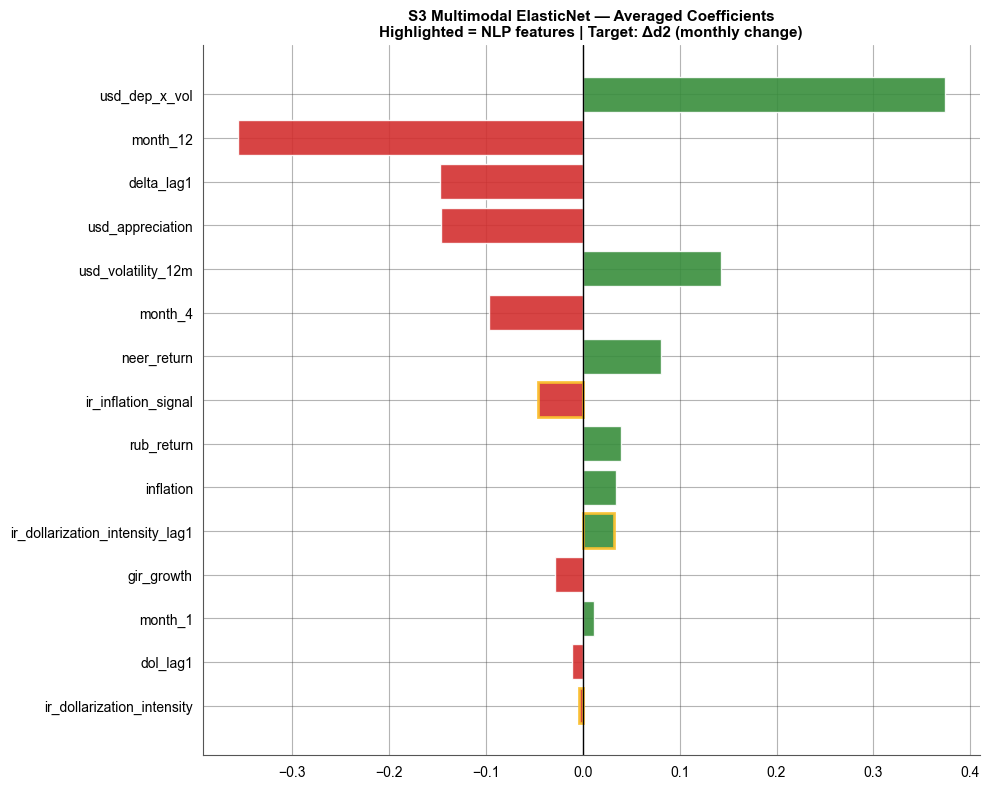

✅ S3 results saved: Outputs\modelling_results_s3.xlsx


In [51]:
# ── DM test — final model vs baseline ────────────────────────────────────────

def dm_test(y, p1, p2):
    mask = ~np.isnan(p1) & ~np.isnan(p2)
    e1 = y[mask] - p1[mask]
    e2 = y[mask] - p2[mask]
    d = e1**2 - e2**2
    n, d_bar = len(d), np.mean(d)
    var_d = np.var(d, ddof=1) / n
    if var_d <= 0: return np.nan, np.nan
    dm = d_bar / np.sqrt(var_d)
    hlm = np.sqrt((n + 1 - 2 + 1*(1-1)/n) / n)
    dm *= hlm
    p = 2 * (1 - scipy_stats.t.cdf(abs(dm), df=n-1))
    return round(dm, 4), round(p, 6)

dm_stat, dm_p = dm_test(y, pred_s, pred_f)
print(f'\nDM test (ElasticNet final vs baseline): stat={dm_stat}  p={dm_p}')

# ── Coefficient plot ──────────────────────────────────────────────────────────
coef_all_df = pd.DataFrame({
    'Feature': vars_,
    'Coefficient': coef_f
}).sort_values('Coefficient', key=abs, ascending=True)

fig, ax = plt.subplots(figsize=(10, 8), facecolor='white')
ax.set_facecolor('white')

plot_df = coef_all_df[coef_all_df['Coefficient'] != 0]

colors = ['#d32f2f' if c < 0 else '#388e3c' for c in plot_df['Coefficient']]

bars = ax.barh(plot_df['Feature'], plot_df['Coefficient'],
               color=colors, alpha=0.9)

for i, feat in enumerate(plot_df['Feature']):
    if feat in FINAL_NLP:
        bars[i].set_edgecolor('#fbc02d')  # gold highlight
        bars[i].set_linewidth(2)

# Use dark axis line (not white)
ax.axvline(0, color='black', linewidth=1)

# Clean styling
ax.set_title(
    'S3 Multimodal ElasticNet — Averaged Coefficients\n'
    'Highlighted = NLP features | Target: Δd2 (monthly change)',
    fontweight='bold', fontsize=11, color='black'
)

ax.tick_params(axis='both', colors='black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, 's3_multimodal_coefficients.png'),
    dpi=300,  # important for print
    facecolor='white',
    bbox_inches='tight'
)

plt.show()
# ── Save results ──────────────────────────────────────────────────────────────
s3_out = os.path.join(OUTPUT_DIR, 'modelling_results_s3.xlsx')
with pd.ExcelWriter(s3_out, engine='openpyxl') as writer:
    pd.DataFrame([
        {'Model': 'Structured ElasticNet',
         'RMSE': rmse_s, 'MAE': mae_s, 'R²': r2_s, 'DirAcc': da_s},
        {'Model': 'Multimodal ElasticNet',
         'RMSE': rmse_f, 'MAE': mae_f, 'R²': r2_f, 'DirAcc': da_f,
         'RMSE_improvement_%': (rmse_s - rmse_f) / rmse_s * 100,
         'NLP_vars': str(FINAL_NLP)},
    ]).to_excel(writer, sheet_name='Main_Comparison', index=False)

    pd.DataFrame([
        {'Benchmark': 'Structured', 'Challenger': 'Multimodal',
         'DM_stat': dm_stat, 'p_value': dm_p},
    ]).to_excel(writer, sheet_name='DM_Test', index=False)

    coef_all_df.to_excel(writer, sheet_name='Coefficients', index=False)

    pred_df = df_s3[['Date', TARGET]].copy()
    pred_df['Structured'] = pred_s
    pred_df['Multimodal'] = pred_f
    pred_df.to_excel(writer, sheet_name='Predictions', index=False)

print(f'✅ S3 results saved: {s3_out}')